# ProstT5 Speculative Decoding — Folding Direction (AA → 3Di), CNN, FlexProfile, and Probabilistic Profile drafters

This notebook benchmarks **speculative decoding** for ProstT5 *folding* (AA → 3Di) using one or more folding drafters, through a single shared pipeline.

**Pick the drafter in Section 0** (`DRAFTER = "cnn" | "flexprofile" | "probprofile" | "both" | "all"`); everything downstream adapts automatically.

**Drafters**
- **CNN** — tiny 234k-param Conv2d head that reads the **shared** ProstT5 encoder hidden states and predicts all 3Di positions in one parallel pass. Near-zero VRAM overhead.
- **FlexProfile** — [ProtProfileMD](https://doi.org/10.64898/2026.01.21.700698) (`finnlueth/ProtProfileMD`): ProstT5 encoder + LoRA + linear head, trained with KL to MD-derived 3Di FlexProfiles. Loads its **own** ~1.2B-param encoder ⇒ large VRAM overhead.
- **Probabilistic Profile** — builds smoothed 3Di emission profiles from precomputed projected homolog 3Di rows in `prostT5/folding_MSA-2`, with prefix-context backoff. Near-zero static VRAM overhead.

**Integration:** HuggingFace `assistant_model` API — no custom speculative-decoding loop. Greedy speculative decoding is output-identical to plain greedy.

**Direction:** AA → 3Di. Input `<AA2fold> M A L W ...`; output 20-letter lowercase 3Di.

**Per-drafter outputs** are written to `benchmark_results/folding_spec_dec/<drafter>/` (and mirrored to Drive); cross-drafter comparison plots go to `.../comparison/`. Results are **checkpointed after every protein** (resume-safe).

**New vs the single-drafter notebooks:** Section 8 profiles each drafter's **speed + VRAM overhead** (encoder vs drafter-for-K vs decoder-verification), and Section 11 adds the timing-breakdown and speedup-vs-VRAM-overhead comparison plots.

In [1]:
%pip install -q tiktoken sentencepiece
%pip install -q 'accelerate>=0.26.0'
%pip install -q "protobuf>=3.20,<5"
%pip install -q "transformers==4.46.3" "huggingface_hub>=0.23.2,<1.0"
# Pin peft to a version compatible with transformers 4.46.3. Newer peft (>=0.15)
# imports symbols missing from transformers 4.46.3 -> ImportError in get_peft_model.
%pip install -q "peft==0.13.2" safetensors pyyaml datasets pandas matplotlib tqdm
# Do NOT upgrade transformers to 5.x — it breaks the ProstT5 T5Tokenizer.
# IMPORTANT: if peft/transformers were already imported this session, RESTART the
# runtime after this cell (Colab: Runtime -> Restart session) so the pins take effect.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 13.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.17 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 98.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.5 MB/s eta 

In [2]:
%matplotlib inline
import os, sys, time, statistics, gc, pickle, json as _json, shutil as _shutil
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as _cm
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

os.environ["USE_TF"] = "0"
from transformers import (T5Tokenizer, AutoModelForSeq2SeqLM, GenerationConfig,
                          PreTrainedModel, T5EncoderModel)
from transformers.modeling_outputs import ModelOutput, Seq2SeqLMOutput
from transformers.generation.utils import GenerationMixin

try:
    from google.colab import drive
    drive.mount('/content/drive')
    USE_DRIVE = True
    DRIVE_ROOT = '/content/drive/MyDrive'
except Exception:
    USE_DRIVE = False
    DRIVE_ROOT = None

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch: {torch.__version__}  |  Device: {device}  |  Drive: {USE_DRIVE}")
if device.type == "cpu":
    print("WARNING: running on CPU — timings will not reflect realistic GPU latency.")

Mounted at /content/drive
PyTorch: 2.11.0+cu128  |  Device: cuda:0  |  Drive: True


In [3]:
# @title [Optional] GPU Memory Cleanup — run before re-running the notebook
_to_clear = ['model', 'encoder', 'cnn', 'cnn_assistant',
             'flex_drafter', 'flex_assistant', 'assistants']
for _v in _to_clear:
    if _v in globals():
        del globals()[_v]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f"GPU memory cleared.  Free: {free/1e9:.1f} GB / {total/1e9:.1f} GB total")
else:
    print("No CUDA GPU — nothing to clear.")

GPU memory cleared.  Free: 15.5 GB / 15.6 GB total


## 0. Drafter Selection

Choose which folding drafter(s) to run. Everything below — model loading, result folders, benchmark loop, plots — keys off `DRAFTERS`.

In [4]:
# @title 0. Drafter selection
#   "cnn"        — tiny 234k Conv2d head on the SHARED ProstT5 encoder (≈0 VRAM overhead)
#   "flexprofile"— ProtProfileMD: ProstT5 encoder + LoRA + head, its OWN ~1.2B encoder
#   "probprofile"— probabilistic 3Di profile drafter from precomputed projected homolog rows
#   "both"       — run and compare CNN + FlexProfile without requiring MSA folders
#   "all"        — run and compare all three through the identical pipeline
DRAFTER = "both"   # <-- EDIT ME: "cnn" | "flexprofile" | "probprofile" | "both" | "all"

assert DRAFTER in ("cnn", "flexprofile", "probprofile", "both", "all"), DRAFTER
if DRAFTER == "all":
    DRAFTERS = ["cnn", "flexprofile", "probprofile"]
elif DRAFTER == "both":
    DRAFTERS = ["cnn", "flexprofile"]
else:
    DRAFTERS = [DRAFTER]
DRAFTER_LABEL = {
    "cnn": "Folding CNN",
    "flexprofile": "ProtProfileMD FlexProfile",
    "probprofile": "Probabilistic Profile",
}
DRAFTER_COLOR = {"cnn": "#2e86de", "flexprofile": "#e67e22", "probprofile": "#27ae60"}
DRAFTER_MARKER = {"cnn": "o", "flexprofile": "s", "probprofile": "^"}
print(f"Selected drafter(s): {DRAFTERS}")


Selected drafter(s): ['cnn', 'flexprofile']


## 1. Configuration & Model Loading

In [5]:
# @title 1A. Configuration + per-drafter result paths
PROSTT5_NAME = "Rostlab/ProstT5_fp16"
NOTEBOOK_DIR = Path(".").resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

# 3Di alphabet — same 20 letters as AAs but lowercase
DI_LETTERS = "acdefghiklmnpqrstvwy"
assert len(DI_LETTERS) == 20
DI_TO_IDX = {c: i for i, c in enumerate(DI_LETTERS)}
GAP_CHARS = {"-", ".", "*"}
PROFILE_SMOOTHING = 0.5
PROB_PROFILE_CONTEXT = 2      # prefix-context order for the probabilistic drafter
PROB_PROFILE_N = 16           # projected homolog rows used per protein

# ── Benchmark / timing protocol ──────────────────────────────────────────────
# Speedup is measured by INTERLEAVING: for each protein we time plain enc-dec and
# then HF speculative decoding back-to-back, inside the same repeat, and take the
# median of the per-repeat ratios. Because both timings happen a fraction of a
# second apart, GPU clock/thermal drift moves both together and cancels in the
# ratio — removing the large run-to-run speedup variance. (See `benchmark_protein`.)
NUM_REPEATS = 3   # timed repeats per protein; report median of per-repeat ratios
NUM_WARMUP  = 1   # untimed warmup runs before timing
USE_FP16    = True

# Plot colours — covers every integer K from 1..16 via a continuous colormap
_pal_cmap = _cm.get_cmap("tab10")
PALETTE = {k: _pal_cmap(i % 10) for i, k in enumerate(range(1, 17))}
BLUE, ORANGE, GREEN, GRAY = "#2e86de", "#f39c12", "#27ae60", "#7f8c8d"

# ── Locate folding CNN checkpoint (AA → 3Di) — only if 'cnn' selected ─────────
def _readable(path: Path) -> bool:
    try:
        with open(path, "rb") as f:
            f.read(4)
        return True
    except OSError:
        return False

CNN_CKPT = None
if "cnn" in DRAFTERS:
    for candidate in [
        NOTEBOOK_DIR / "model.pt",
        NOTEBOOK_DIR / "CNN_fromAA_to3Di.pt",
        NOTEBOOK_DIR / "cnn_chkpnt_AA_CNN" / "model.pt",
        NOTEBOOK_DIR / "prostT5" / "cnn_chkpnt_AA_CNN" / "model.pt",
        NOTEBOOK_DIR / "cnn_chkpnt_folding" / "model.pt",
        NOTEBOOK_DIR.parent / "cnn_chkpnt_folding" / "model.pt",
        *([] if not USE_DRIVE else [
            Path(DRIVE_ROOT) / "models" / "CNN_fromAA_to3Di.pt",
            Path(DRIVE_ROOT) / "model.pt",
        ]),
    ]:
        if _readable(candidate):
            CNN_CKPT = candidate
            break
    if CNN_CKPT is None:
        raise FileNotFoundError(
            "Folding CNN checkpoint not found or not readable.\n"
            "Upload cnn_chkpnt_AA_CNN/model.pt or cnn_chkpnt_folding/model.pt to the notebook dir or Google Drive."
        )
    print(f"Folding CNN checkpoint: {CNN_CKPT}")

# ── Precomputed projected 3Di MSA directory for probabilistic profile drafter ─
PROB_PROFILE_MSA_DIR = None
if "probprofile" in DRAFTERS:
    _profile_drive_candidates = [] if not USE_DRIVE else [
        Path(DRIVE_ROOT) / "models" / "folding_MSA-2",
        Path(DRIVE_ROOT) / "folding_MSA-2",
        Path(DRIVE_ROOT) / "prostT5" / "folding_MSA-2",
        Path(DRIVE_ROOT) / "Speculative-Decoding-ProstT5" / "prostT5" / "folding_MSA-2",
    ]
    for candidate in [
        NOTEBOOK_DIR / "prostT5" / "folding_MSA-2",
        NOTEBOOK_DIR / "folding_MSA-2",
        *_profile_drive_candidates,
    ]:
        if candidate.exists() and candidate.is_dir():
            PROB_PROFILE_MSA_DIR = candidate
            break
    if PROB_PROFILE_MSA_DIR is None:
        raise FileNotFoundError(
            "Probabilistic profile drafter selected but prostT5/folding_MSA-2 was not found."
        )
    print(f"Probabilistic profile MSA dir: {PROB_PROFILE_MSA_DIR}")

# ── Per-drafter result folders ───────────────────────────────────────────────
#   local:  result/folding_spec_dec/<drafter>/
#   records: result/folding_spec_dec/run_records/<drafter>_runs.csv
#   drive:  MyDrive/models/folding_spec_dec_results/<drafter>/
#   shared comparison plots: result/folding_spec_dec/comparison/
RESULTS_ROOT = NOTEBOOK_DIR / "result" / "folding_spec_dec"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
COMPARISON_DIR = RESULTS_ROOT / "comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)
RUN_RECORD_DIR = RESULTS_ROOT / "run_records"
RUN_RECORD_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_RESULTS_ROOT = (Path(DRIVE_ROOT) / "models" / "folding_spec_dec_results") if USE_DRIVE else None
DRIVE_COMPARISON_DIR = (DRIVE_RESULTS_ROOT / "comparison") if USE_DRIVE else None
if USE_DRIVE:
    DRIVE_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

def make_paths(name: str) -> dict:
    local = RESULTS_ROOT / name
    local.mkdir(parents=True, exist_ok=True)
    drive = (DRIVE_RESULTS_ROOT / name) if USE_DRIVE else None
    if drive is not None:
        drive.mkdir(parents=True, exist_ok=True)
    return {
        "dir":          local,
        "drive_dir":    drive,
        "checkpoint":   local / "folding_spec_dec_checkpoint.pkl",
        "results_csv":  local / "folding_spec_dec_results.csv",
        "preds_json":   local / "folding_spec_dec_predictions.json",
        "alpha_csv":    local / "folding_alpha_results.csv",
        "overhead_csv": local / "folding_drafter_overhead.csv",
        "run_records_csv": RUN_RECORD_DIR / f"{name}_runs.csv",
        "run_predictions_json": RUN_RECORD_DIR / f"{name}_predictions.json",
    }

PATHS = {name: make_paths(name) for name in DRAFTERS}
print(f"Results root: {RESULTS_ROOT}")
for name in DRAFTERS:
    print(f"  {name:11s} -> {PATHS[name]['dir']}")
print(f"  comparison  -> {COMPARISON_DIR}")
print(f"  run records -> {RUN_RECORD_DIR}")

/tmp/ipykernel_981/3110315657.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _pal_cmap = _cm.get_cmap("tab10")


Folding CNN checkpoint: /content/drive/MyDrive/models/CNN_fromAA_to3Di.pt
Results root: /content/benchmark_results/folding_spec_dec
  cnn         -> /content/benchmark_results/folding_spec_dec/cnn
  flexprofile -> /content/benchmark_results/folding_spec_dec/flexprofile
  comparison  -> /content/benchmark_results/folding_spec_dec/comparison


In [6]:
# @title 1B. Drafter + assistant class definitions (no GPU load yet)
"""
CNN and FlexProfile are prefix-independent and predict all L 3Di positions in a
single parallel pass. The probabilistic profile drafter rebuilds smoothed 3Di
emissions from projected homolog rows and conditions on the accepted/generated
3Di prefix during assisted generation.
"""
import yaml

# ── CNN drafter head (AA→3Di) ────────────────────────────────────────────────
class FoldingCNN(nn.Module):
    """CNN head: encoder hidden states (1024-dim) → 3Di logits (20 classes)."""
    def __init__(self, num_tokens: int = 20, hidden: int = 32, in_dim: int = 1024):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(in_dim, hidden, kernel_size=(7, 1), padding=(3, 0)),
            nn.ReLU(),
            nn.Dropout(0.0),
            nn.Conv2d(hidden, num_tokens, kernel_size=(7, 1), padding=(3, 0)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.permute(0, 2, 1).unsqueeze(-1)   # (B, 1024, L, 1)
        x = self.classifier(x)                 # (B, 20, L, 1)
        return x.squeeze(-1).permute(0, 2, 1)  # (B, L, 20)


# ── FlexProfile drafter (ProtProfileMD: encoder + LoRA + profile head) ───────
class ProfileHeadLinear(nn.Module):
    """Linear head for profile generation from T5 embeddings (mirrors ProtProfileMD)."""
    def __init__(self, dropout=0.1, hidden_size=1024, num_classes=20):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.dropout(x)
        x = self.classifier(x)
        x = torch.softmax(x, dim=2)
        return x


class FlexProfileDrafter(nn.Module):
    """ProstT5 encoder + LoRA + profile head → per-residue 3Di probability profiles."""
    def __init__(self, device="cpu", dtype=torch.float32):
        super().__init__()
        self.device = device
        self.dtype = dtype
        self._encoder = None
        self._profile_head = None

    @classmethod
    def from_huggingface(cls, device="cpu", dtype=torch.float32):
        from huggingface_hub import snapshot_download
        import safetensors.torch
        from peft import LoraConfig, get_peft_model

        drafter = cls(device=device, dtype=dtype)
        repo_dir = snapshot_download(repo_id="finnlueth/ProtProfileMD")

        with open(os.path.join(repo_dir, "train_config.yaml"), "r") as f:
            train_config = yaml.safe_load(f)

        adapter_name = train_config["metadata"]["adapter_name"]
        adapter_dir = os.path.join(repo_dir, adapter_name)
        st_path = os.path.join(adapter_dir, "adapter_model.safetensors")

        print(f"ProtProfileMD repo: {repo_dir}")
        print(f"  Base model:   {train_config['model']['base_model']}")

        print("Loading ProstT5 encoder for ProtProfileMD...")
        encoder_pp = T5EncoderModel.from_pretrained(
            "Rostlab/ProstT5_fp16", torch_dtype=dtype, low_cpu_mem_usage=True,
        )

        profile_head = ProfileHeadLinear(**train_config["model"]["profile_head_kwargs"])

        lora_cfg = train_config["training"]["lora"].copy()
        lora_cfg.pop("modules_to_save", None)
        encoder_pp = get_peft_model(encoder_pp, peft_config=LoraConfig(**lora_cfg),
                                    adapter_name=adapter_name)

        assert os.path.isdir(adapter_dir), f"adapter dir missing: {adapter_dir}"
        encoder_pp.load_adapter(model_id=adapter_dir, adapter_name=adapter_name)
        print(f"  LoRA adapter loaded from {adapter_dir}")

        assert os.path.exists(st_path), f"weights file missing: {st_path}"
        state = safetensors.torch.load_file(st_path)

        def _find_head_key(target):
            cands = [k for k in state if "profile_head" in k and k.endswith(target)]
            trained = [k for k in cands if "modules_to_save" in k]
            chosen = trained or cands
            return chosen[0] if chosen else None

        head_state = {}
        for target in profile_head.state_dict().keys():
            k = _find_head_key(target)
            if k is not None:
                head_state[target] = state[k]
        missing = set(profile_head.state_dict().keys()) - set(head_state.keys())
        if missing:
            raise RuntimeError(f"Profile-head weights not found in {st_path}: missing {sorted(missing)}")
        profile_head.load_state_dict(head_state, strict=True)

        w = profile_head.classifier.weight.detach().float()
        assert w.abs().sum() > 0, "profile head weights are all zero -- load failed"

        encoder_pp = encoder_pp.merge_and_unload()
        print("  LoRA merged into encoder.")

        drafter._encoder = encoder_pp.to(device).eval()
        drafter._profile_head = profile_head.to(device).eval()
        n_enc = sum(p.numel() for p in encoder_pp.parameters())
        n_head = sum(p.numel() for p in profile_head.parameters())
        print(f"  Encoder params: {n_enc/1e6:.1f}M, Head params: {n_head:,}")
        return drafter

    @torch.inference_mode()
    def predict_profiles(self, input_ids, attention_mask):
        """Run encoder + head, return (L, 20) probability profiles (trims prefix + EOS)."""
        enc_out = self._encoder(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        hidden = enc_out.last_hidden_state
        hidden_trimmed = hidden[:, 1:-1, :]
        probs = self._profile_head(hidden_trimmed.float())
        return probs[0]

    @torch.inference_mode()
    def predict_profiles_for_aa_sequence(self, tokenizer, aa_seq: str):
        text = "<AA2fold> " + " ".join(list(aa_seq.upper()))
        enc = tokenizer([text], add_special_tokens=True, return_tensors="pt")
        enc = {k: v.to(self.device) for k, v in enc.items()}
        return self.predict_profiles(enc["input_ids"], enc["attention_mask"])


# ── FlexProfile HF assistant wrapper ─────────────────────────────────────────
class FlexProfileAssistantModel(PreTrainedModel):
    """HF `assistant_model` for ProtProfileMD (own encoder + profile head, no decoder)."""

    def __init__(self, config, flex_drafter: FlexProfileDrafter, di_token_ids):
        super().__init__(config)
        self._flex = flex_drafter
        self._di_token_ids = di_token_ids
        self.config.is_encoder_decoder = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=8, num_assistant_tokens_schedule="constant",
            assistant_confidence_threshold=None,   # force static draft length; no DISCO early-exit
            do_sample=False, max_length=3000,
        )
        self._cached_logits = None
        self._cached_hidden_id = None

    @property
    def device(self):
        return self._flex.device

    def get_encoder(self):
        return self._flex._encoder

    @staticmethod
    def _hidden_tensor(encoder_outputs):
        if hasattr(encoder_outputs, "last_hidden_state"):
            return encoder_outputs.last_hidden_state
        return encoder_outputs[0]

    def _full_vocab_logits(self, encoder_outputs):
        h = self._hidden_tensor(encoder_outputs)[:, 1:-1, :]
        probs = self._flex._profile_head(h.float())[0]
        vocab_size = self.config.vocab_size
        full = torch.full((probs.shape[0], vocab_size), -1e4,
                          device=probs.device, dtype=probs.dtype)
        for di_idx, tok_id in enumerate(self._di_token_ids):
            full[:, tok_id] = probs[:, di_idx]
        return full

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None, **kwargs):
        return {"decoder_input_ids": decoder_input_ids, "encoder_outputs": encoder_outputs}

    def forward(self, decoder_input_ids=None, encoder_outputs=None, **kwargs):
        if encoder_outputs is not None:
            h_id = id(self._hidden_tensor(encoder_outputs))
            if self._cached_hidden_id != h_id:
                self._cached_logits = self._full_vocab_logits(encoder_outputs)
                self._cached_hidden_id = h_id
        n = decoder_input_ids.shape[1]
        if self._cached_logits is not None:
            n_ret = min(n, self._cached_logits.shape[0])
            logits = self._cached_logits[:n_ret].unsqueeze(0)
            if n_ret < n:
                pad = torch.full((1, n - n_ret, logits.shape[-1]), -1e4,
                                 device=logits.device, dtype=logits.dtype)
                logits = torch.cat([logits, pad], dim=1)
        else:
            logits = torch.zeros(1, n, self.config.vocab_size,
                                 device=self.device, dtype=torch.float32)
        return Seq2SeqLMOutput(logits=logits)

    @torch.inference_mode()
    def generate(self, inputs=None, generation_config=None, logits_processor=None,
                 stopping_criteria=None, synced_gpus=None, streamer=None, **kwargs):
        from transformers.generation.utils import GenerateEncoderDecoderOutput
        generation_config = generation_config or self.generation_config
        decoder_input_ids = kwargs.pop("decoder_input_ids", None)
        if decoder_input_ids is None:
            decoder_input_ids = kwargs.pop("input_ids", inputs)
        encoder_outputs = kwargs.get("encoder_outputs")
        max_new_tokens = int(kwargs.get("max_new_tokens", generation_config.num_assistant_tokens))
        return_dict = kwargs.get("return_dict_in_generate", True)
        output_scores = kwargs.get("output_scores", True)
        if decoder_input_ids is None:
            raise ValueError("FlexProfileAssistantModel.generate requires decoder_input_ids")
        full_logits = self._full_vocab_logits(encoder_outputs)
        pos = decoder_input_ids.shape[1] - 1
        new_tokens, scores = [], ()
        for i in range(max_new_tokens):
            p = pos + i
            if p >= full_logits.shape[0]:
                break
            logit_vec = full_logits[p]
            new_tokens.append(int(logit_vec.argmax().item()))
            if output_scores:
                scores = scores + (logit_vec.unsqueeze(0).unsqueeze(0),)
        if new_tokens:
            ext = torch.tensor([new_tokens], device=decoder_input_ids.device, dtype=decoder_input_ids.dtype)
            sequences = torch.cat([decoder_input_ids, ext], dim=-1)
        else:
            sequences = decoder_input_ids
        if return_dict:
            return GenerateEncoderDecoderOutput(sequences=sequences, scores=scores or None)
        return sequences


# ── Probabilistic profile drafter from projected folding homologs ─────────────
def read_fasta_records(path: Path) -> list[tuple[str, str]]:
    records, name, buf = [], None, []
    for line in path.read_text(encoding="utf-8").splitlines():
        if line.startswith(">"):
            if name is not None:
                records.append((name, "".join(buf)))
            name = line[1:].split()[0] if line[1:].split() else line[1:]
            buf = []
        else:
            buf.append(line.strip())
    if name is not None:
        records.append((name, "".join(buf)))
    return records


def _first_existing_file(paths: list[Path]) -> Path | None:
    for path in paths:
        if path.exists() and path.is_file():
            return path
    return None


def load_prob_profile_rows(uid: str, aa_len: int) -> list[str]:
    d = PROB_PROFILE_MSA_DIR / uid
    candidates = [
        d / "homologs_projected_to_query_3di.fasta",
        d / "homologs_projected_to_query_3Di.fasta",
        d / "projected_3di.fasta",
        d / "projected_3Di.fasta",
        d / "homologs_3di.fasta",
        d / "homologs_3Di.fasta",
    ]
    path = _first_existing_file(candidates)
    if path is None:
        fasta_files = sorted(d.glob("*.fasta")) + sorted(d.glob("*.fa")) + sorted(d.glob("*.a3m"))
        if len(fasta_files) == 1:
            path = fasta_files[0]
    if path is None:
        raise FileNotFoundError(
            f"{uid}: no projected homolog 3Di FASTA found under {d}. "
            "Expected homologs_projected_to_query_3di.fasta or another single FASTA/A3M file."
        )
    rows = [seq[:aa_len].lower() for _, seq in read_fasta_records(path)]
    if not rows:
        raise ValueError(f"{uid}: no projected homolog rows in {path}")
    return rows


class FoldingProbabilisticProfileDrafter:
    """Smoothed column emissions plus prefix-context backoff over projected 3Di rows."""

    def __init__(self, projected_rows: list[str], length: int,
                 smoothing: float = PROFILE_SMOOTHING,
                 max_context: int = PROB_PROFILE_CONTEXT):
        self.length = length
        self.smoothing = smoothing
        self.max_context = max_context
        counts = np.full((length, len(DI_LETTERS)), smoothing, dtype=np.float64)
        self.context_counts = defaultdict(lambda: np.zeros(len(DI_LETTERS), dtype=np.float64))

        for row in projected_rows:
            projected = list(row[:length]) + [None] * max(0, length - len(row))
            projected = [c if c in DI_TO_IDX else None for c in projected]
            observed = [(pos, c) for pos, c in enumerate(projected) if c is not None]
            for pos, tok in observed:
                counts[pos, DI_TO_IDX[tok]] += 1.0
            for pos, tok in observed:
                for ctx_len in range(min(max_context, pos), -1, -1):
                    ctx = projected[pos - ctx_len:pos]
                    if any(c is None for c in ctx):
                        continue
                    self.context_counts[(pos, tuple(ctx))][DI_TO_IDX[tok]] += 1.0

        self.static_counts = counts
        self.static_probs = counts / counts.sum(axis=1, keepdims=True)

    def probs_for_prefix(self, prefix_syms: list[str], max_context: int | None = None) -> np.ndarray:
        pos = len(prefix_syms)
        if pos >= self.length:
            return np.full(len(DI_LETTERS), 1.0 / len(DI_LETTERS), dtype=np.float64)
        max_context = self.max_context if max_context is None else max_context
        available = min(max_context, pos)
        for ctx_len in range(available, -1, -1):
            ctx = tuple(prefix_syms[-ctx_len:]) if ctx_len > 0 else tuple()
            key = (pos, ctx)
            if key in self.context_counts:
                counts = self.context_counts[key] + self.smoothing
                return counts / counts.sum()
        return self.static_probs[pos]

    def logits_for_prefix(self, prefix_syms: list[str]) -> torch.Tensor:
        probs = np.clip(self.probs_for_prefix(prefix_syms), 1e-9, 1.0)
        return torch.from_numpy(np.log(probs).astype(np.float32))


class ProbabilisticProfileAssistantModel(PreTrainedModel, GenerationMixin):
    """HF assistant wrapper for the per-protein probabilistic profile drafter."""

    def __init__(self, config, prostt5_encoder, di_token_ids, token_id_to_di):
        super().__init__(config)
        self._encoder = prostt5_encoder
        self._di_token_ids = di_token_ids
        self._token_id_to_di = token_id_to_di
        self.config.is_encoder_decoder = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=5, num_assistant_tokens_schedule="constant",
            assistant_confidence_threshold=None,   # force static draft length; no DISCO early-exit
            do_sample=False, max_length=3000,
        )
        self._active_drafter = None
        self._active_uid = None

    def set_drafter(self, uid: str, drafter: FoldingProbabilisticProfileDrafter):
        self._active_uid = uid
        self._active_drafter = drafter

    def get_encoder(self):
        return self._encoder

    def _validate_model_kwargs(self, model_kwargs):
        return

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None,
                                       attention_mask=None, **kwargs):
        return {"decoder_input_ids": decoder_input_ids, "encoder_outputs": encoder_outputs,
                "attention_mask": attention_mask}

    def _prefix_symbols(self, decoder_input_ids) -> list[str]:
        ids = decoder_input_ids[0, 1:].detach().cpu().tolist()
        return [self._token_id_to_di[t] for t in ids if t in self._token_id_to_di]

    def forward(self, decoder_input_ids=None, encoder_outputs=None, attention_mask=None, **kwargs):
        vocab_size = self.config.vocab_size
        full = torch.full((1, decoder_input_ids.shape[1], vocab_size), -1e4,
                          device=decoder_input_ids.device, dtype=torch.float32)
        if self._active_drafter is not None:
            prefix = self._prefix_symbols(decoder_input_ids)
            row = self._active_drafter.logits_for_prefix(prefix).to(decoder_input_ids.device)
            for di_idx, tok_id in enumerate(self._di_token_ids):
                full[0, -1, tok_id] = row[di_idx]
        return Seq2SeqLMOutput(logits=full)

    @torch.inference_mode()
    def generate(self, inputs=None, generation_config=None, logits_processor=None,
                 stopping_criteria=None, synced_gpus=None, streamer=None, **kwargs):
        from transformers.generation.utils import GenerateEncoderDecoderOutput
        generation_config = generation_config or self.generation_config
        decoder_input_ids = kwargs.pop("decoder_input_ids", None)
        if decoder_input_ids is None:
            decoder_input_ids = kwargs.pop("input_ids", inputs)
        max_new_tokens = int(kwargs.get("max_new_tokens", generation_config.num_assistant_tokens))
        return_dict = kwargs.get("return_dict_in_generate", True)
        output_scores = kwargs.get("output_scores", True)
        if decoder_input_ids is None:
            raise ValueError("ProbabilisticProfileAssistantModel.generate requires decoder_input_ids")

        sequences = decoder_input_ids
        scores = ()
        if self._active_drafter is None:
            if return_dict:
                return GenerateEncoderDecoderOutput(sequences=sequences, scores=None)
            return sequences

        for _ in range(max_new_tokens):
            prefix = self._prefix_symbols(sequences)
            if len(prefix) >= self._active_drafter.length:
                break
            row = self._active_drafter.logits_for_prefix(prefix).to(sequences.device)
            full = torch.full((1, 1, self.config.vocab_size), -1e4,
                              device=sequences.device, dtype=torch.float32)
            for di_idx, tok_id in enumerate(self._di_token_ids):
                full[0, 0, tok_id] = row[di_idx]
            next_token = int(full[0, 0].argmax().item())
            sequences = torch.cat([
                sequences,
                torch.tensor([[next_token]], device=sequences.device, dtype=sequences.dtype),
            ], dim=-1)
            if output_scores:
                scores = scores + (full,)

        if return_dict:
            return GenerateEncoderDecoderOutput(sequences=sequences, scores=scores or None)
        return sequences


print("Drafter + assistant classes defined.")

Drafter + assistant classes defined.


In [7]:
# @title 1C. Load ProstT5 verifier + selected drafter(s)  (records VRAM overhead)
tokenizer = T5Tokenizer.from_pretrained(PROSTT5_NAME, do_lower_case=False, legacy=True)

dtype = torch.float16 if (USE_FP16 and device.type == "cuda") else torch.float32
model = AutoModelForSeq2SeqLM.from_pretrained(
    PROSTT5_NAME, low_cpu_mem_usage=True, torch_dtype=dtype,
).to(device).eval()
encoder = model.get_encoder()
print(f"ProstT5 verifier: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

# ── Token-id mappings (shared) ───────────────────────────────────────────────
DI_TOKEN_IDS           = [tokenizer.encode(f" {di}", add_special_tokens=False)[0] for di in DI_LETTERS]
CNN_IDX_TO_DI_TOKEN_ID = {i: tid for i, tid in enumerate(DI_TOKEN_IDS)}
DI_TOKEN_ID_TO_CNN_IDX = {tid: i for i, tid in enumerate(DI_TOKEN_IDS)}
DECODER_START_TOKEN_ID = model.config.decoder_start_token_id
for di, tid in zip(DI_LETTERS[:3], DI_TOKEN_IDS[:3]):
    assert tokenizer.decode([tid]).strip() == di

def _vram_alloc():
    return torch.cuda.memory_allocated() if device.type == "cuda" else 0

# Static VRAM added by each drafter's weights (the headline "overhead" number)
DRAFTER_VRAM   = {}
DRAFTER_PARAMS = {}

# ── CNN drafter: tiny head, SHARES the verifier encoder ──────────────────────
cnn = None
if "cnn" in DRAFTERS:
    if device.type == "cuda": torch.cuda.synchronize()
    _before = _vram_alloc()
    cnn = FoldingCNN().to(device).eval()
    _ck = torch.load(CNN_CKPT, map_location=device, weights_only=False)
    cnn.load_state_dict(_ck.get("state_dict", _ck), strict=True)
    if device.type == "cuda": torch.cuda.synchronize()
    DRAFTER_VRAM["cnn"]   = _vram_alloc() - _before
    DRAFTER_PARAMS["cnn"] = sum(p.numel() for p in cnn.parameters())
    print(f"Folding CNN: {DRAFTER_PARAMS['cnn']:,} params, "
          f"+{DRAFTER_VRAM['cnn']/1e6:.2f} MB VRAM (shares ProstT5 encoder)")

# ── FlexProfile drafter: its OWN LoRA-merged encoder + head ──────────────────
flex_drafter = None
if "flexprofile" in DRAFTERS:
    if device.type == "cuda": torch.cuda.synchronize()
    _before = _vram_alloc()
    flex_drafter = FlexProfileDrafter.from_huggingface(device=device, dtype=dtype)
    if device.type == "cuda": torch.cuda.synchronize()
    DRAFTER_VRAM["flexprofile"]   = _vram_alloc() - _before
    DRAFTER_PARAMS["flexprofile"] = (sum(p.numel() for p in flex_drafter._encoder.parameters())
                                     + sum(p.numel() for p in flex_drafter._profile_head.parameters()))
    print(f"FlexProfile: {DRAFTER_PARAMS['flexprofile']:,} params, "
          f"+{DRAFTER_VRAM['flexprofile']/1e9:.2f} GB VRAM (own encoder)")

if "probprofile" in DRAFTERS:
    DRAFTER_VRAM["probprofile"] = 0
    DRAFTER_PARAMS["probprofile"] = 0
    print(f"Probabilistic Profile: per-protein CPU count tables from {PROB_PROFILE_MSA_DIR} "
          f"(N={PROB_PROFILE_N}, context={PROB_PROFILE_CONTEXT}); +0 MB static VRAM")

if device.type == "cuda":
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory: {used:.1f} GB used / {total:.1f} GB total")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

training_history.csv: 0.00B [00:00, ?B/s]

README.md:   0%|          | 0.00/518 [00:00<?, ?B/s]

train_config.yaml: 0.00B [00:00, ?B/s]

training_history.png:   0%|          | 0.00/53.9k [00:00<?, ?B/s]

ProtProfileMD repo: /root/.cache/huggingface/hub/models--finnlueth--ProtProfileMD/snapshots/16be78ef5c7db694f426371c593548bfdfbb335e
  Base model:   Rostlab/ProstT5
Loading ProstT5 encoder for ProtProfileMD...
  LoRA adapter loaded from /root/.cache/huggingface/hub/models--finnlueth--ProtProfileMD/snapshots/16be78ef5c7db694f426371c593548bfdfbb335e/ProtProfileMD_LoRA
  LoRA merged into encoder.
  Encoder params: 1208.2M, Head params: 20,500
FlexProfile: 1,208,184,852 params, +3.22 GB VRAM (own encoder)
GPU memory: 10.5 GB used / 15.6 GB total


## 2. Dataset — Protein Test Set

In [8]:
# @title 2A. Load FASTA files (generated by prostT5_baseline_performance.ipynb)
def parse_fasta(path: Path) -> dict:
    seqs, cur = {}, None
    for line in path.read_text(encoding="utf-8").splitlines():
        if line.startswith(">"):
            cur = line[1:].split()[0]; seqs[cur] = ""
        elif cur:
            seqs[cur] += line.strip()
    return seqs

_drive_candidates = [] if not USE_DRIVE else [
    Path(DRIVE_ROOT) / "models",
    Path(DRIVE_ROOT) / "benchmark_data",
    Path(DRIVE_ROOT) / "prostT5" / "benchmark_data",
    Path(DRIVE_ROOT) / "Speculative-Decoding-ProstT5" / "prostT5" / "benchmark_data",
    Path(DRIVE_ROOT) / "prostT5_benchmarks",
]
DATA_DIR = None
for candidate in [
    NOTEBOOK_DIR / "benchmark_data",
    Path("/content/benchmark_data"),
    Path("/content/prostT5/benchmark_data"),
    *_drive_candidates,
]:
    if (candidate / "test_set_AA.fasta").exists():
        DATA_DIR = candidate
        break
if DATA_DIR is None:
    raise FileNotFoundError(
        "test_set_AA.fasta not found.\n"
        "Run prostT5_baseline_performance.ipynb first to generate the FASTA files."
    )

aa_seqs = parse_fasta(DATA_DIR / "test_set_AA.fasta")
di_seqs = parse_fasta(DATA_DIR / "test_set_3Di.fasta")
ALL_PROTEINS = [
    {"id": uid, "AA": aa_seqs[uid].upper(), "3Di": di_seqs[uid].lower()}
    for uid in aa_seqs if uid in di_seqs and len(aa_seqs[uid]) == len(di_seqs[uid])
]
lengths = [len(r["AA"]) for r in ALL_PROTEINS]
print(f"Loaded {len(ALL_PROTEINS)} proteins from {DATA_DIR}")
print(f"Length range: {min(lengths)}-{max(lengths)} AA  |  median: {sorted(lengths)[len(lengths)//2]}")

Loaded 100 proteins from /content/drive/MyDrive/models
Length range: 46-2554 AA  |  median: 419


In [9]:
# @title 2B. Hyperparameters — edit before running
K_VALUES     = [1, 4, 8, 12]   # draft lengths to sweep
NUM_PROTEINS = 10            # max proteins to benchmark; None = all

benchmark_data = ALL_PROTEINS[:NUM_PROTEINS] if NUM_PROTEINS is not None else ALL_PROTEINS
benchmark_data = sorted(benchmark_data, key=lambda r: len(r["AA"]))
print(f"Dataset: {len(benchmark_data)} proteins (of {len(ALL_PROTEINS)} total)")
print(f"K_VALUES={K_VALUES}  NUM_REPEATS={NUM_REPEATS}  NUM_WARMUP={NUM_WARMUP}  drafters={DRAFTERS}")

Dataset: 10 proteins (of 100 total)
K_VALUES=[1, 4, 8, 12]  NUM_REPEATS=3  NUM_WARMUP=1  drafters=['cnn', 'flexprofile']


In [10]:
# @title 2C. Checkpointing (per drafter)
# Speedup is measured INLINE and INTERLEAVED in Section 4/6: for each protein we
# time plain enc-dec and HF speculative decoding back-to-back in the same repeat,
# then take the median of per-repeat ratios. No precomputed baseline is needed.
def save_checkpoint(name, state):
    state["timestamp"] = datetime.now().isoformat()
    with open(PATHS[name]["checkpoint"], "wb") as f:
        pickle.dump(state, f)
    if USE_DRIVE and PATHS[name]["drive_dir"] is not None:
        _shutil.copy(PATHS[name]["checkpoint"],
                     PATHS[name]["drive_dir"] / PATHS[name]["checkpoint"].name)

def load_checkpoint(name):
    p = PATHS[name]["checkpoint"]
    if p.exists():
        with open(p, "rb") as f:
            return pickle.load(f)
    if USE_DRIVE and PATHS[name]["drive_dir"] is not None:
        dp = PATHS[name]["drive_dir"] / p.name
        if dp.exists():
            _shutil.copy(dp, p)
            print(f"[{name}] restored checkpoint from Drive.")
            with open(p, "rb") as f:
                return pickle.load(f)
    return None



RUN_RECORD_FIELDS = [
    "run_key", "timestamp", "drafter", "protein_id", "length", "K",
    "num_repeats", "num_warmup", "prob_profile_n", "prob_profile_context",
    "t_encdec", "t_encdec_std", "t_hf", "t_hf_std", "speedup", "speedup_std", "hf_ok",
]
RUN_RECORD_INDEX: dict[str, set[str]] = {}
RUN_RECORD_ROWS: dict[str, list[dict]] = {}
RUN_RECORD_PREDICTIONS: dict[str, dict] = {}


def _run_key(name: str, uid: str, K: int) -> str:
    # Include config that changes the output/timing, so old incompatible rows do not suppress new runs.
    return "|".join([
        str(name), str(uid), f"K={int(K)}", f"repeats={NUM_REPEATS}", f"warmup={NUM_WARMUP}",
        f"probN={PROB_PROFILE_N if name == 'probprofile' else ''}",
        f"probP={PROB_PROFILE_CONTEXT if name == 'probprofile' else ''}",
    ])


def _load_run_records(name: str):
    path = PATHS[name]["run_records_csv"]
    if path.exists():
        rows = pd.read_csv(path).to_dict("records")
    else:
        rows = []
    keys = {str(r.get("run_key")) for r in rows if r.get("run_key")}
    pred_path = PATHS[name]["run_predictions_json"]
    preds = {}
    if pred_path.exists():
        with open(pred_path) as f:
            preds = _json.load(f)
    RUN_RECORD_ROWS[name] = rows
    RUN_RECORD_INDEX[name] = keys
    RUN_RECORD_PREDICTIONS[name] = preds
    print(f"[{name}] run-record index: {len(keys)} completed K-runs from {path}")


def _has_run_record(name: str, uid: str, K: int) -> bool:
    return _run_key(name, uid, K) in RUN_RECORD_INDEX.setdefault(name, set())


def _record_result_row(name: str, uid: str, length: int, K: int, r: dict | None, ok: bool) -> dict:
    row = dict(
        run_key=_run_key(name, uid, K),
        timestamp=datetime.now().isoformat(),
        drafter=name,
        protein_id=uid,
        length=length,
        K=int(K),
        num_repeats=NUM_REPEATS,
        num_warmup=NUM_WARMUP,
        prob_profile_n=(PROB_PROFILE_N if name == "probprofile" else ""),
        prob_profile_context=(PROB_PROFILE_CONTEXT if name == "probprofile" else ""),
        t_encdec=(r.get("t_encdec") if r else float("nan")),
        t_encdec_std=(r.get("t_encdec_std") if r else float("nan")),
        t_hf=(r.get("t_hf") if r else float("nan")),
        t_hf_std=(r.get("t_hf_std") if r else float("nan")),
        speedup=(r.get("speedup") if r else float("nan")),
        speedup_std=(r.get("speedup_std") if r else float("nan")),
        hf_ok=bool(ok and r is not None),
    )
    return row


def append_run_record(name: str, row: dict, pred: str | None = None):
    # Called only after timing/generation has completed; lookup and I/O are outside measured wall timers.
    key = row["run_key"]
    if key in RUN_RECORD_INDEX.setdefault(name, set()):
        return
    path = PATHS[name]["run_records_csv"]
    path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame([row], columns=RUN_RECORD_FIELDS).to_csv(
        path,
        mode="a",
        index=False,
        header=not path.exists(),
    )
    RUN_RECORD_INDEX[name].add(key)
    RUN_RECORD_ROWS.setdefault(name, []).append(row)
    if pred is not None:
        preds = RUN_RECORD_PREDICTIONS.setdefault(name, {})
        preds.setdefault(row["protein_id"], {})[str(row["K"])] = pred
        with open(PATHS[name]["run_predictions_json"], "w") as f:
            _json.dump(preds, f)


print("Checkpoint and run-record helpers ready.")

Checkpoint helpers ready.


## 3. Assistant Models — HuggingFace-Compatible Wrappers

The CNN assistant wraps the tiny head on the **shared** ProstT5 encoder; the FlexProfile assistant (defined in 1B) carries its **own** encoder. Both expose K argmax 3Di drafts to `model.generate(..., assistant_model=...)`.

In [11]:
# @title 3. Build assistant model(s)
class CNNAssistantModel(PreTrainedModel):
    """Wraps the folding CNN (AA→3Di) as a HF-compatible assistant for speculative decoding."""
    config_class = type(model.config)

    def __init__(self, config, prostt5_encoder, cnn_head, di_token_ids):
        super().__init__(config)
        self._encoder      = prostt5_encoder
        self._cnn          = cnn_head
        self._di_token_ids = di_token_ids
        self.config.is_encoder_decoder     = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=5, num_assistant_tokens_schedule="constant",
            assistant_confidence_threshold=None,   # force static draft length; no DISCO early-exit
            do_sample=False, max_length=3000,
        )
        self._cached_logits    = None
        self._cached_hidden_id = None

    def _full_vocab_logits(self, encoder_outputs) -> torch.Tensor:
        hidden   = encoder_outputs[0]
        h        = hidden[:, 1:-1, :]
        logits20 = self._cnn(h.float())[0]
        vocab_size = self.config.vocab_size
        full = torch.full((logits20.shape[0], vocab_size), -1e4,
                          device=logits20.device, dtype=logits20.dtype)
        for cnn_idx, tok_id in enumerate(self._di_token_ids):
            full[:, tok_id] = logits20[:, cnn_idx]
        return full

    def get_encoder(self):
        return self._encoder

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None,
                                       attention_mask=None, **kwargs):
        return {"decoder_input_ids": decoder_input_ids, "encoder_outputs": encoder_outputs,
                "attention_mask": attention_mask}

    def forward(self, decoder_input_ids=None, encoder_outputs=None, attention_mask=None, **kwargs):
        if encoder_outputs is not None:
            h_id = id(encoder_outputs[0])
            if self._cached_hidden_id != h_id:
                self._cached_logits    = self._full_vocab_logits(encoder_outputs)
                self._cached_hidden_id = h_id
        n = decoder_input_ids.shape[1]
        if self._cached_logits is not None:
            n_ret  = min(n, self._cached_logits.shape[0])
            logits = self._cached_logits[:n_ret].unsqueeze(0)
            if n_ret < n:
                pad    = torch.full((1, n - n_ret, logits.shape[-1]), -1e4,
                                    device=logits.device, dtype=logits.dtype)
                logits = torch.cat([logits, pad], dim=1)
        else:
            logits = torch.zeros(1, n, self.config.vocab_size, device=device, dtype=torch.float32)
        return ModelOutput(logits=logits)

    @torch.inference_mode()
    def generate(self, inputs=None, generation_config=None, logits_processor=None,
                 stopping_criteria=None, synced_gpus=None, streamer=None, **kwargs):
        # Custom greedy draft: emit EXACTLY num_assistant_tokens (=K) candidates, capped
        # only by remaining sequence length. Bypasses HF's assisted-generation path so no
        # confidence threshold / schedule can shorten the draft (matches FlexProfile/ProbProfile).
        from transformers.generation.utils import GenerateEncoderDecoderOutput
        generation_config = generation_config or self.generation_config
        decoder_input_ids = kwargs.pop("decoder_input_ids", None)
        if decoder_input_ids is None:
            decoder_input_ids = kwargs.pop("input_ids", inputs)
        encoder_outputs = kwargs.get("encoder_outputs")
        max_new_tokens = int(kwargs.get("max_new_tokens", generation_config.num_assistant_tokens))
        return_dict = kwargs.get("return_dict_in_generate", True)
        output_scores = kwargs.get("output_scores", True)
        if decoder_input_ids is None:
            raise ValueError("CNNAssistantModel.generate requires decoder_input_ids")
        full_logits = self._full_vocab_logits(encoder_outputs)
        pos = decoder_input_ids.shape[1] - 1
        new_tokens, scores = [], ()
        for i in range(max_new_tokens):
            p = pos + i
            if p >= full_logits.shape[0]:
                break
            logit_vec = full_logits[p]
            new_tokens.append(int(logit_vec.argmax().item()))
            if output_scores:
                scores = scores + (logit_vec.unsqueeze(0).unsqueeze(0),)
        if new_tokens:
            ext = torch.tensor([new_tokens], device=decoder_input_ids.device, dtype=decoder_input_ids.dtype)
            sequences = torch.cat([decoder_input_ids, ext], dim=-1)
        else:
            sequences = decoder_input_ids
        if return_dict:
            return GenerateEncoderDecoderOutput(sequences=sequences, scores=scores or None)
        return sequences


assistants = {}
if "cnn" in DRAFTERS:
    cnn_assistant = CNNAssistantModel(
        config=model.config, prostt5_encoder=encoder, cnn_head=cnn, di_token_ids=DI_TOKEN_IDS,
    ).to(device).eval()
    assistants["cnn"] = cnn_assistant
if "flexprofile" in DRAFTERS:
    flex_assistant = FlexProfileAssistantModel(
        config=model.config, flex_drafter=flex_drafter, di_token_ids=DI_TOKEN_IDS,
    ).to(device).eval()
    assistants["flexprofile"] = flex_assistant
if "probprofile" in DRAFTERS:
    prob_profile_assistant = ProbabilisticProfileAssistantModel(
        config=model.config,
        prostt5_encoder=encoder,
        di_token_ids=DI_TOKEN_IDS,
        token_id_to_di={tid: di for di, tid in zip(DI_LETTERS, DI_TOKEN_IDS)},
    ).to(device).eval()
    assistants["probprofile"] = prob_profile_assistant

for name, a in assistants.items():
    print(f"{name:11s}: assistant ready (is_encoder_decoder={a.config.is_encoder_decoder})")

CNNAssistantModel has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


cnn        : assistant ready (is_encoder_decoder=True)
flexprofile: assistant ready (is_encoder_decoder=True)


## 4. Helper Functions

In [12]:
# @title 4. Helper functions
def _sync():
    if device.type == "cuda":  torch.cuda.synchronize()
    elif device.type == "mps": torch.mps.synchronize()

def _format_aa(seq: str) -> str:
    """ProstT5 folding input: <AA2fold> M A L W M R ..."""
    return "<AA2fold> " + " ".join(list(seq.upper()))

def _decode_3di(token_ids) -> str:
    ids = token_ids if isinstance(token_ids, list) else token_ids.tolist()
    s = tokenizer.decode(ids, skip_special_tokens=True)
    return "".join(s.split()).lower()

_PROB_PROFILE_CACHE = {}

def get_prob_profile_drafter(uid: str, aa_len: int) -> FoldingProbabilisticProfileDrafter:
    key = (uid, aa_len, PROB_PROFILE_N, PROB_PROFILE_CONTEXT)
    if key not in _PROB_PROFILE_CACHE:
        rows = load_prob_profile_rows(uid, aa_len)[:PROB_PROFILE_N]
        _PROB_PROFILE_CACHE[key] = FoldingProbabilisticProfileDrafter(rows, aa_len)
    return _PROB_PROFILE_CACHE[key]

def _prepare_assistant(name: str, uid: str, aa_len: int, K: int):
    a = assistants[name]
    a.generation_config.num_assistant_tokens = K
    if name == "probprofile":
        a.set_drafter(uid, get_prob_profile_drafter(uid, aa_len))
    _reset_assistant_cache(a)
    return a

def _reset_assistant_cache(a):
    """Force cached parallel drafters to recompute on the next generate()."""
    if hasattr(a, "_cached_logits"):    a._cached_logits = None
    if hasattr(a, "_cached_hidden_id"): a._cached_hidden_id = None


@torch.inference_mode()
def run_encdec(aa_seq: str) -> str:
    """Single plain enc-dec greedy pass → 3Di string. Used ONLY by the sanity check."""
    L   = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    out = model.generate(input_ids=enc.input_ids, attention_mask=enc.attention_mask,
                         max_length=L + 2, do_sample=False, num_beams=1)
    return _decode_3di(out[0])[:L]


@torch.inference_mode()
def run_hf_assisted(name: str, uid: str, aa_seq: str, K: int) -> str:
    """Single speculative-decoding pass → 3Di string. Used ONLY by the sanity check."""
    L   = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    a   = _prepare_assistant(name, uid, L, K)
    out = model.generate(input_ids=enc.input_ids, attention_mask=enc.attention_mask,
                         max_length=L + 2, do_sample=False, num_beams=1, assistant_model=a)
    return _decode_3di(out[0])[:L]


@torch.inference_mode()
def benchmark_protein(name: str, item: dict, k_values=None):
    """Interleaved enc-dec vs HF-assisted timing for ONE protein, all K, one drafter.

    Why interleave: enc-dec and HF run back-to-back inside the SAME repeat, so any
    GPU clock/thermal drift moves BOTH together and cancels in the per-repeat ratio.
    The headline `speedup` is the median of those per-repeat ratios; `speedup_std`
    is their spread = the true measurement noise (small for a fixed protein). Every
    protein and drafter use the identical warmup + repeat protocol, so results are
    directly comparable and not biased by which moment the baseline was measured.

    Returns: {K: dict(t_encdec, t_encdec_std, t_hf, t_hf_std, speedup, speedup_std, pred)}.
    """
    uid, aa_seq = item["id"], item["AA"]
    selected_K = list(K_VALUES if k_values is None else k_values)
    if not selected_K:
        return {}
    L   = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    a   = assistants[name]
    kw_base = dict(input_ids=enc.input_ids, attention_mask=enc.attention_mask,
                   max_length=L + 2, do_sample=False, num_beams=1)

    def gen_base():
        return model.generate(**kw_base)

    def gen_hf(K):
        _prepare_assistant(name, uid, L, K)    # identical work every call
        return model.generate(assistant_model=a, **kw_base)

    # Warmup: exercise enc-dec and every K so clocks + allocator are warm and equal
    for _ in range(NUM_WARMUP):
        gen_base()
        for K in selected_K:
            gen_hf(K)
    _sync()

    base_t = []
    hf_t   = {K: [] for K in selected_K}
    preds  = {}
    for _ in range(NUM_REPEATS):
        _sync(); t0 = time.perf_counter(); gen_base(); _sync()
        base_t.append(time.perf_counter() - t0)
        for K in selected_K:
            _sync(); t0 = time.perf_counter(); out = gen_hf(K); _sync()
            hf_t[K].append(time.perf_counter() - t0)
            preds[K] = _decode_3di(out[0])[:L]

    res = {}
    for K in selected_K:
        ratios = [b / h for b, h in zip(base_t, hf_t[K]) if h > 0]
        res[K] = dict(
            t_encdec=statistics.median(base_t),
            t_encdec_std=float(np.std(base_t)),
            t_hf=statistics.median(hf_t[K]),
            t_hf_std=float(np.std(hf_t[K])),
            speedup=statistics.median(ratios) if ratios else float("nan"),
            speedup_std=float(np.std(ratios)) if ratios else float("nan"),
            pred=preds[K],
        )
    return res

print("Helpers defined.")

Helpers defined.


## 5. Sanity Check — HF Output Must Match Plain Greedy Output

Greedy speculative decoding is provably output-identical to plain greedy (Leviathan et al., 2023). Verified per selected drafter on the 5 shortest proteins.

In [13]:
# @title 5. Sanity check per drafter
print("Verifying correctness on 5 shortest proteins...\n")
test_proteins = sorted(benchmark_data, key=lambda r: len(r["AA"]))[:5]
all_ok = True
for item in test_proteins:
    uid, aa_seq = item["id"], item["AA"]
    L = len(aa_seq)
    ref_3di = run_encdec(aa_seq)  # returns the 3Di string directly
    for name in DRAFTERS:
        for K in K_VALUES:
            try:
                pred_3di = run_hf_assisted(name, uid, aa_seq, K)
                match = (pred_3di == ref_3di)
                status = "PASS" if match else "FAIL"
                if not match: all_ok = False
            except Exception as exc:
                status = f"ERROR: {exc}"; all_ok = False
            print(f"  {status:5s}  {name:11s}  {uid} L={L}  K={K}")
print(f"\n{'ALL CORRECT' if all_ok else 'FAILURES DETECTED — check assistant wrapper(s)'}")

Verifying correctness on 5 shortest proteins...



Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


  PASS   cnn          P01542 L=46  K=1
  PASS   cnn          P01542 L=46  K=4
  PASS   cnn          P01542 L=46  K=8
  PASS   cnn          P01542 L=46  K=12
  PASS   flexprofile  P01542 L=46  K=1
  PASS   flexprofile  P01542 L=46  K=4
  PASS   flexprofile  P01542 L=46  K=8
  PASS   flexprofile  P01542 L=46  K=12
  PASS   cnn          P02798 L=61  K=1
  PASS   cnn          P02798 L=61  K=4
  PASS   cnn          P02798 L=61  K=8
  PASS   cnn          P02798 L=61  K=12
  PASS   flexprofile  P02798 L=61  K=1
  PASS   flexprofile  P02798 L=61  K=4
  PASS   flexprofile  P02798 L=61  K=8
  PASS   flexprofile  P02798 L=61  K=12
  PASS   cnn          P01308 L=110  K=1
  FAIL   cnn          P01308 L=110  K=4
  PASS   cnn          P01308 L=110  K=8
  PASS   cnn          P01308 L=110  K=12
  PASS   flexprofile  P01308 L=110  K=1
  FAIL   flexprofile  P01308 L=110  K=4
  PASS   flexprofile  P01308 L=110  K=8
  PASS   flexprofile  P01308 L=110  K=12
  PASS   cnn          Q57733 L=147  K=1
  PASS   c

## 6. Full Benchmark — HF Assisted (per drafter, K sweep)

For each protein: the enc-dec baseline is measured **once** (cached, shared), then every selected drafter is benchmarked across all K. Each drafter keeps its **own** checkpoint/CSV/JSON under its subfolder; checkpointed after every protein (resume-safe).

Speedup = t_encdec_baseline / t_hf_assisted.

In [14]:
# @title 6. Main benchmark loop (resume-aware, per-drafter run records)
# Before timing, each (drafter, protein, K, config) is checked against the in-memory
# run-record index loaded from result/folding_spec_dec/run_records/. If present, it
# is skipped. The lookup happens outside the measured wall timers; run records are
# appended only after generation/timing completes.
state = {}
for name in DRAFTERS:
    _load_run_records(name)
    ck = load_checkpoint(name)
    if ck is not None:
        _raw = ck.get("completed", {})
        completed = ({uid: set(ks) for uid, ks in _raw.items()} if isinstance(_raw, dict)
                     else {uid: set() for uid in _raw})
        state[name] = {"results": ck.get("results", []),
                       "predictions": ck.get("predictions", {}),
                       "completed": completed,
                       "alpha_results": ck.get("alpha_results", {})}
        print(f"[{name}] checkpoint restored: {len(completed)} proteins present.")
    else:
        state[name] = {"results": [], "predictions": {}, "completed": {}, "alpha_results": {}}
        print(f"[{name}] fresh checkpoint state.")

# Hydrate checkpoint-like state from the run records. This keeps plotting/loading compatible
# while the run-record CSV remains the source of truth for skip decisions.
for name in DRAFTERS:
    st = state[name]
    preds_from_records = RUN_RECORD_PREDICTIONS.get(name, {})
    for row in RUN_RECORD_ROWS.get(name, []):
        if not bool(row.get("hf_ok", False)):
            continue
        uid = str(row["protein_id"])
        K = int(row["K"])
        if any(r.get("id") == uid and int(r.get("K")) == K and r.get("drafter") == name for r in st["results"]):
            continue
        st["results"].append(dict(
            id=uid, length=int(row["length"]), drafter=name, K=K,
            t_encdec=float(row["t_encdec"]), t_encdec_std=float(row["t_encdec_std"]),
            t_hf=float(row["t_hf"]), t_hf_std=float(row["t_hf_std"]),
            speedup=float(row["speedup"]), speedup_std=float(row["speedup_std"]), hf_ok=True,
        ))
        st["completed"].setdefault(uid, set()).add(K)
        if uid in preds_from_records:
            st["predictions"].setdefault(uid, {"preds_by_K": {}})["preds_by_K"].update(preds_from_records[uid])

def _protein_done(uid):
    return all(all(_has_run_record(n, uid, K) for K in K_VALUES) for n in DRAFTERS)

_remaining = [it for it in benchmark_data if not _protein_done(it["id"])]
print(f"\nProteins remaining (any drafter/K): {len(_remaining)}/{len(benchmark_data)}\n")

for item in tqdm(_remaining, desc="Proteins"):
    uid, aa_seq = item["id"], item["AA"]
    L = len(aa_seq)

    for name in DRAFTERS:
        st = state[name]
        pending_K = [K for K in K_VALUES if not _has_run_record(name, uid, K)]
        if not pending_K:
            continue

        try:
            res = benchmark_protein(name, item, k_values=pending_K)   # lookup already done; timed work only inside
            ok = True
        except Exception as e:
            print(f"  {name} {uid}: benchmark failed - {e}")
            res, ok = {}, False

        preds_k = st["predictions"].get(uid, {}).get("preds_by_K", {})
        for K in pending_K:
            r = res.get(K)
            row = _record_result_row(name, uid, L, K, r, ok)
            pred = r.get("pred") if (ok and r is not None) else None
            append_run_record(name, row, pred=pred)
            if ok and r is not None:
                st["results"].append(dict(
                    id=uid, length=L, drafter=name, K=K,
                    t_encdec=r["t_encdec"], t_encdec_std=r["t_encdec_std"],
                    t_hf=r["t_hf"], t_hf_std=r["t_hf_std"],
                    speedup=r["speedup"], speedup_std=r["speedup_std"], hf_ok=True,
                ))
                preds_k[str(K)] = r["pred"]
            else:
                st["results"].append(dict(
                    id=uid, length=L, drafter=name, K=K,
                    t_encdec=float("nan"), t_encdec_std=float("nan"),
                    t_hf=float("nan"), t_hf_std=float("nan"),
                    speedup=float("nan"), speedup_std=float("nan"), hf_ok=False,
                ))

        st["predictions"][uid] = {"AA": aa_seq, "3Di": item["3Di"], "preds_by_K": preds_k}
        st["completed"].setdefault(uid, set()).update(pending_K)
        save_checkpoint(name, {
            "results": st["results"], "predictions": st["predictions"],
            "completed": {u: list(ks) for u, ks in st["completed"].items()},
            "alpha_results": st["alpha_results"],
        })

    gc.collect()

# Final per-drafter CSV/JSON mirrors from in-memory state for the existing analysis cells.
for name in DRAFTERS:
    st = state[name]
    pd.DataFrame(st["results"]).to_csv(PATHS[name]["results_csv"], index=False)
    with open(PATHS[name]["preds_json"], "w") as f:
        _json.dump(st["predictions"], f)
    if USE_DRIVE and PATHS[name]["drive_dir"] is not None:
        _shutil.copy(PATHS[name]["results_csv"], PATHS[name]["drive_dir"] / PATHS[name]["results_csv"].name)
        _shutil.copy(PATHS[name]["preds_json"],  PATHS[name]["drive_dir"] / PATHS[name]["preds_json"].name)
    print(f"[{name}] saved {len(st['results'])} rows -> {PATHS[name]['results_csv'].name}")
    print(f"[{name}] run records -> {PATHS[name]['run_records_csv']}")
print("\nBenchmark complete.")


[cnn] fresh start.
[flexprofile] fresh start.

Proteins remaining (any drafter): 10/10



Proteins:   0%|          | 0/10 [00:00<?, ?it/s]

[cnn] saved 40 rows -> folding_spec_dec_results.csv
[flexprofile] saved 40 rows -> folding_spec_dec_results.csv

Benchmark complete.


## 7. Acceptance Rate α — Theoretical Analysis

α is the per-position probability the drafter `q` agrees with the verifier `p` (both over the 20 3Di tokens):
$$\alpha = \mathbb{E}_x\left[\sum_t \min(p(t|x), q(t|x))\right]$$
Leviathan et al. Theorem 3.8: expected tokens/step $= (1-\alpha^{K+1})/(1-\alpha)$ — the speedup ceiling at zero drafter overhead. Computed per selected drafter.

In [15]:
# @title 7. Compute alpha per drafter (greedy / temperature=1.0)
@torch.inference_mode()
def drafter_probs20(name: str, enc, uid: str | None = None, greedy_3di: str | None = None) -> torch.Tensor:
    """(L,20) probability profile over 3Di for the given drafter."""
    if name == "cnn":
        h = encoder(input_ids=enc.input_ids, attention_mask=enc.attention_mask).last_hidden_state[:, 1:-1, :]
        return torch.softmax(cnn(h.float())[0], dim=-1)
    if name == "flexprofile":
        return flex_drafter.predict_profiles(enc.input_ids, enc.attention_mask)  # already softmaxed
    if name == "probprofile":
        assert uid is not None and greedy_3di is not None
        drafter = get_prob_profile_drafter(uid, len(greedy_3di))
        rows = []
        for pos in range(len(greedy_3di)):
            probs = drafter.probs_for_prefix(list(greedy_3di[:pos]), PROB_PROFILE_CONTEXT)
            rows.append(torch.tensor(probs, device=device, dtype=torch.float32))
        return torch.stack(rows, dim=0)
    raise KeyError(name)


@torch.inference_mode()
def compute_alpha(name: str, uid: str, aa_seq: str):
    L   = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    greedy_out = model.generate(input_ids=enc.input_ids, attention_mask=enc.attention_mask,
                                max_length=L + 2, do_sample=False, num_beams=1)
    greedy_3di = _decode_3di(greedy_out[0])[:L]
    dec_ids = greedy_out[:, :-1]
    fwd = model(input_ids=enc.input_ids, attention_mask=enc.attention_mask, decoder_input_ids=dec_ids)
    p_logits = fwd.logits[0, :L]
    q20 = drafter_probs20(name, enc, uid=uid, greedy_3di=greedy_3di)
    L_eff = min(L, p_logits.shape[0], q20.shape[0])
    p_probs = torch.softmax(p_logits[:L_eff].float(), dim=-1)
    q_probs = torch.zeros_like(p_probs)
    for i, tid in enumerate(DI_TOKEN_IDS):
        q_probs[:, tid] = q20[:L_eff, i]
    alpha_per_pos = torch.minimum(p_probs, q_probs).sum(dim=-1)
    return float(alpha_per_pos.mean()), float(alpha_per_pos.std())


for name in DRAFTERS:
    st = state[name]
    todo = [it for it in benchmark_data if it["id"] not in st["alpha_results"]]
    print(f"[{name}] alpha: {len(st['alpha_results'])} done, {len(todo)} remaining.")
    for item in tqdm(todo, desc=f"alpha-{name}"):
        uid, aa_seq = item["id"], item["AA"]
        try:
            a_mean, a_std = compute_alpha(name, uid, aa_seq)
        except Exception as e:
            print(f"  {name} {uid}: alpha failed - {e}")
            a_mean, a_std = float("nan"), float("nan")
        st["alpha_results"][uid] = {"alpha_mean": a_mean, "alpha_std": a_std, "length": len(aa_seq)}
        save_checkpoint(name, {
            "results": st["results"], "predictions": st["predictions"],
            "completed": {u: list(ks) for u, ks in st["completed"].items()},
            "alpha_results": st["alpha_results"],
        })
    adf = pd.DataFrame([{"id": k, **v} for k, v in st["alpha_results"].items()])
    adf.to_csv(PATHS[name]["alpha_csv"], index=False)
    if USE_DRIVE and PATHS[name]["drive_dir"] is not None:
        _shutil.copy(PATHS[name]["alpha_csv"], PATHS[name]["drive_dir"] / PATHS[name]["alpha_csv"].name)
    if len(adf):
        print(f"[{name}] mean alpha = {adf['alpha_mean'].mean():.4f}  -> ceiling 1/(1-a) = "
              f"{1/(1-adf['alpha_mean'].mean()):.2f}x")


[cnn] alpha: 0 done, 10 remaining.


alpha-cnn:   0%|          | 0/10 [00:00<?, ?it/s]

[cnn] mean alpha = 0.7140  -> ceiling 1/(1-a) = 3.50x
[flexprofile] alpha: 0 done, 10 remaining.


alpha-flexprofile:   0%|          | 0/10 [00:00<?, ?it/s]

[flexprofile] mean alpha = 0.3266  -> ceiling 1/(1-a) = 1.49x


## 8. Drafter Overhead Profiling — Speed + VRAM

Decomposes one speculative-decoding round into its three measurable costs, per drafter and per K:
- **Encoder** — one ProstT5 (verifier) encoder pass (shared; same for both drafters).
- **Drafter (K tokens)** — drafter-specific compute to produce K drafts. Both drafters are one-shot (compute all positions at once), so this is ~flat in K — for FlexProfile it includes its **own** encoder pass; for the CNN it's just the tiny head on already-computed hidden states.
- **Decoder verify** — one verifier decoder forward over the K+1 drafted positions (grows with K).

Also records the drafter's **static VRAM** (from Section 1C) and **peak activation VRAM** during drafting. Saved per drafter and combined to `comparison/`.

In [16]:
# @title 8. Profile encoder vs drafter(K) vs decoder-verify + VRAM
# Profile on a few representative proteins spanning the length range.
N_PROFILE = min(5, len(benchmark_data))
_idx = np.linspace(0, len(benchmark_data) - 1, N_PROFILE).round().astype(int)
profile_proteins = [benchmark_data[i] for i in _idx]
print(f"Profiling {len(profile_proteins)} proteins: "
      f"{[ (p['id'], len(p['AA'])) for p in profile_proteins ]}")

def _median_time(fn):
    for _ in range(NUM_WARMUP): fn()
    _sync()
    ts = []
    for _ in range(NUM_REPEATS):
        _sync(); t0 = time.perf_counter(); fn(); _sync()
        ts.append(time.perf_counter() - t0)
    return statistics.median(ts)

def _peak_vram(fn):
    if device.type != "cuda":
        fn(); return 0
    torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    fn(); torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated()

@torch.inference_mode()
def time_encoder(enc):
    return _median_time(lambda: encoder(input_ids=enc.input_ids, attention_mask=enc.attention_mask))

@torch.inference_mode()
def time_decoder_verify(enc, K):
    enc_out = encoder(input_ids=enc.input_ids, attention_mask=enc.attention_mask)
    dec_ids = torch.full((1, K + 1), DECODER_START_TOKEN_ID, device=device, dtype=torch.long)
    return _median_time(lambda: model(encoder_outputs=enc_out,
                                       attention_mask=enc.attention_mask,
                                       decoder_input_ids=dec_ids))

@torch.inference_mode()
def time_drafter(name, enc, K, uid=None, aa_len=None):
    """Drafter cost to produce K drafts (+ peak activation VRAM)."""
    if name == "cnn":
        h = encoder(input_ids=enc.input_ids, attention_mask=enc.attention_mask).last_hidden_state[:, 1:-1, :]
        fn = lambda: cnn(h.float())[0][:K].argmax(-1)
    elif name == "flexprofile":
        fn = lambda: flex_drafter.predict_profiles(enc.input_ids, enc.attention_mask)[:K].argmax(-1)
    elif name == "probprofile":
        drafter = get_prob_profile_drafter(uid, aa_len)
        def fn():
            prefix = []
            for _ in range(K):
                idx = int(drafter.probs_for_prefix(prefix, PROB_PROFILE_CONTEXT).argmax())
                prefix.append(DI_LETTERS[idx])
            return prefix
    else:
        raise KeyError(name)
    t = _median_time(fn)
    peak = _peak_vram(fn)
    return t, peak

overhead_rows = []
for name in DRAFTERS:
    for item in tqdm(profile_proteins, desc=f"overhead-{name}"):
        uid, aa_seq = item["id"], item["AA"]
        L = len(aa_seq)
        enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
        t_enc = time_encoder(enc)
        for K in K_VALUES:
            t_draft, peak = time_drafter(name, enc, K, uid=uid, aa_len=L)
            t_verify = time_decoder_verify(enc, K)
            overhead_rows.append(dict(
                drafter=name, id=uid, length=L, K=K,
                t_encoder=t_enc, t_drafter=t_draft, t_decoder_verify=t_verify,
                drafter_peak_vram_mb=peak / 1e6,
                drafter_static_vram_mb=DRAFTER_VRAM.get(name, 0) / 1e6,
                drafter_params=DRAFTER_PARAMS.get(name, 0),
            ))

overhead_df = pd.DataFrame(overhead_rows)
for name in DRAFTERS:
    sub = overhead_df[overhead_df["drafter"] == name]
    sub.to_csv(PATHS[name]["overhead_csv"], index=False)
    if USE_DRIVE and PATHS[name]["drive_dir"] is not None:
        _shutil.copy(PATHS[name]["overhead_csv"], PATHS[name]["drive_dir"] / PATHS[name]["overhead_csv"].name)
overhead_df.to_csv(COMPARISON_DIR / "drafter_overhead_combined.csv", index=False)
if USE_DRIVE:
    _shutil.copy(COMPARISON_DIR / "drafter_overhead_combined.csv",
                 DRIVE_COMPARISON_DIR / "drafter_overhead_combined.csv")

print("\n=== Mean component timings (ms) + drafter VRAM ===")
for name in DRAFTERS:
    sub = overhead_df[overhead_df["drafter"] == name]
    print(f"\n{DRAFTER_LABEL[name]}  (static VRAM +{DRAFTER_VRAM.get(name,0)/1e6:.1f} MB)")
    print(f"  encoder       : {sub['t_encoder'].mean()*1e3:8.2f} ms")
    print(f"  peak act VRAM : {sub['drafter_peak_vram_mb'].mean():8.1f} MB")
    print(f"  {'K':>3}  {'drafter(ms)':>12}  {'verify(ms)':>11}")
    for K in K_VALUES:
        s = sub[sub["K"] == K]
        print(f"  {K:3d}  {s['t_drafter'].mean()*1e3:12.2f}  {s['t_decoder_verify'].mean()*1e3:11.2f}")

Profiling 5 proteins: [('P01542', 46), ('P01308', 110), ('P0A7Y4', 155), ('P0A988', 366), ('P62944', 937)]


overhead-cnn:   0%|          | 0/5 [00:00<?, ?it/s]

overhead-flexprofile:   0%|          | 0/5 [00:00<?, ?it/s]


=== Mean component timings (ms) + drafter VRAM ===

Folding CNN  (static VRAM +4.7 MB)
  encoder       :   187.41 ms
  peak act VRAM :  10488.4 MB
    K   drafter(ms)   verify(ms)
    1          0.87        44.20
    4          0.85        48.86
    8          0.82        41.90
   12          0.83        44.78

ProtProfileMD FlexProfile  (static VRAM +3221.7 MB)
  encoder       :   188.13 ms
  peak act VRAM :  10579.9 MB
    K   drafter(ms)   verify(ms)
    1        187.99        44.26
    4        189.07        43.14
    8        188.58        48.64
   12        188.22        47.31


## 9. Load Results for Analysis

Reloads everything from disk per drafter (works without the model loaded). Re-run after a kernel restart.

In [17]:
# @title 9. Load saved per-drafter results
def _load_drafter_results(name):
    p = PATHS[name]
    if p["run_records_csv"].exists():
        rdf = pd.read_csv(p["run_records_csv"])
        rdf = rdf.rename(columns={"protein_id": "id"})
    else:
        rdf = pd.read_csv(p["results_csv"]) if p["results_csv"].exists() else pd.DataFrame()
    adf = pd.read_csv(p["alpha_csv"])   if p["alpha_csv"].exists()   else pd.DataFrame(
        columns=["id", "alpha_mean", "alpha_std", "length"])
    odf = pd.read_csv(p["overhead_csv"]) if p["overhead_csv"].exists() else pd.DataFrame()
    preds = {}
    pred_source = p["run_predictions_json"] if p["run_predictions_json"].exists() else p["preds_json"]
    if pred_source.exists():
        with open(pred_source) as f:
            preds = _json.load(f)
    if "drafter" not in rdf.columns and len(rdf):
        rdf["drafter"] = name
    return rdf, adf, odf, preds

def pred_tps(alpha, K):
    if pd.isna(alpha) or alpha >= 0.9999:
        return K + 1
    return (1 - alpha ** (K + 1)) / (1 - alpha)

results_by_drafter, alpha_by_drafter, overhead_by_drafter, preds_by_drafter = {}, {}, {}, {}
_frames = []
for name in DRAFTERS:
    rdf, adf, odf, preds = _load_drafter_results(name)
    if len(rdf) and len(adf):
        rdf = rdf.merge(adf[["id", "alpha_mean", "alpha_std"]], on="id", how="left")
        rdf["pred_tps"] = rdf.apply(lambda r: pred_tps(r.get("alpha_mean"), r["K"]), axis=1)
    results_by_drafter[name]  = rdf
    alpha_by_drafter[name]    = adf
    overhead_by_drafter[name] = odf
    preds_by_drafter[name]    = preds
    if len(rdf):
        _frames.append(rdf)
    print(f"[{name}] results={len(rdf)} rows, alpha={len(adf)}, overhead={len(odf)}, preds={len(preds)}")

df_all = pd.concat(_frames, ignore_index=True) if _frames else pd.DataFrame()
print(f"\nCombined: {len(df_all)} rows across {DRAFTERS}")

[cnn] results=40 rows, alpha=10, overhead=20, preds=10
[flexprofile] results=40 rows, alpha=10, overhead=20, preds=10

Combined: 80 rows across ['cnn', 'flexprofile']


In [18]:
# @title 9B. Display configuration — which K values / drafters to show
_available_K = sorted(df_all["K"].dropna().unique().astype(int).tolist()) if len(df_all) else []
print(f"Available K values: {_available_K}")

K_DISPLAY = _available_K            # edit to subset, e.g. [1, 8]
DRAFTER_DISPLAY = list(DRAFTERS)    # edit to subset, e.g. ["cnn"]

K_DISPLAY = [k for k in K_DISPLAY if k in _available_K]
print(f"K_DISPLAY = {K_DISPLAY}  |  DRAFTER_DISPLAY = {DRAFTER_DISPLAY}")

Available K values: [1, 4, 8, 12]
K_DISPLAY = [1, 4, 8, 12]  |  DRAFTER_DISPLAY = ['cnn', 'flexprofile']


## 10. Results — Tables

In [19]:
# @title 10A. Per-K summary statistics (per drafter)
for name in DRAFTER_DISPLAY:
    rdf = results_by_drafter.get(name)
    if rdf is None or rdf.empty:
        print(f"[{name}] no data"); continue
    print("=" * 72)
    print(f"BENCHMARK — Folding Spec Decode (AA → 3Di)  |  drafter = {DRAFTER_LABEL[name]}")
    print("=" * 72)
    print(f"{'K':>3}  {'alpha':>8}  {'pred tok/step':>13}  {'speedup mean':>12}  "
          f"{'speedup med':>11}  {'HF OK%':>7}")
    print("-" * 64)
    for K in K_DISPLAY:
        sub = rdf[rdf["K"] == K]
        if sub.empty:
            print(f"{K:3d}  (no data)"); continue
        print(f"{K:3d}  {sub['alpha_mean'].mean():8.4f}  {sub['pred_tps'].mean():13.3f}  "
              f"{sub['speedup'].mean():12.3f}  {sub['speedup'].median():11.3f}  "
              f"{sub['hf_ok'].mean()*100:6.1f}%")
    print()

BENCHMARK — Folding Spec Decode (AA → 3Di)  |  drafter = Folding CNN
  K     alpha  pred tok/step  speedup mean  speedup med   HF OK%
----------------------------------------------------------------
  1    0.7140          1.714         1.454        1.467   100.0%
  4    0.7140          2.879         2.256        2.347   100.0%
  8    0.7140          3.436         2.624        2.656   100.0%
 12    0.7140          3.621         2.685        2.723   100.0%

BENCHMARK — Folding Spec Decode (AA → 3Di)  |  drafter = ProtProfileMD FlexProfile
  K     alpha  pred tok/step  speedup mean  speedup med   HF OK%
----------------------------------------------------------------
  1    0.3266          1.327         1.395        1.390   100.0%
  4    0.3266          1.484         1.896        1.970   100.0%
  8    0.3266          1.491         2.141        2.137   100.0%
 12    0.3266          1.491         2.169        2.199   100.0%



In [20]:
# @title 10B. Predicted vs measured tokens/step (per drafter)
for name in DRAFTER_DISPLAY:
    rdf = results_by_drafter.get(name)
    if rdf is None or rdf.empty:
        continue
    adf = alpha_by_drafter[name]
    print(f"--- {DRAFTER_LABEL[name]}  (global mean alpha = {adf['alpha_mean'].mean():.4f}) ---")
    print(f"{'K':>3}  {'pred tok/step':>13}  {'speedup mean':>12}  {'ratio':>7}")
    for K in K_DISPLAY:
        sub = rdf[rdf["K"] == K]
        if sub.empty:
            continue
        pred = sub["pred_tps"].mean(); meas = sub["speedup"].mean()
        ratio = meas / pred if pred > 0 else float("nan")
        print(f"{K:3d}  {pred:13.3f}  {meas:12.3f}  {ratio:7.3f}")
    print()

--- Folding CNN  (global mean alpha = 0.7140) ---
  K  pred tok/step  speedup mean    ratio
  1          1.714         1.454    0.848
  4          2.879         2.256    0.783
  8          3.436         2.624    0.764
 12          3.621         2.685    0.742

--- ProtProfileMD FlexProfile  (global mean alpha = 0.3266) ---
  K  pred tok/step  speedup mean    ratio
  1          1.327         1.395    1.052
  4          1.484         1.896    1.277
  8          1.491         2.141    1.436
 12          1.491         2.169    1.455



In [21]:
# @title 10C. Sequence recovery vs ground-truth 3Di (per drafter)
def seq_recovery(pred, gt):
    n = min(len(pred), len(gt))
    return sum(p == g for p, g in zip(pred[:n], gt[:n])) / n if n else 0.0

for name in DRAFTER_DISPLAY:
    preds = preds_by_drafter.get(name, {})
    if not preds or not K_DISPLAY:
        continue
    k0 = str(K_DISPLAY[0])
    vals = []
    for item in benchmark_data:
        uid, gt = item["id"], item["3Di"]
        if uid in preds:
            pred = preds[uid].get("preds_by_K", {}).get(k0, "")
            if pred:
                vals.append(seq_recovery(pred, gt))
    if vals:
        print(f"{DRAFTER_LABEL[name]:32s}  recovery@K={K_DISPLAY[0]}: "
              f"{np.mean(vals):.3f} +/- {np.std(vals):.3f}  "
              f"(greedy spec-dec ⇒ identical across K)")

Folding CNN                       recovery@K=1: 0.708 +/- 0.119  (greedy spec-dec ⇒ identical across K)
ProtProfileMD FlexProfile         recovery@K=1: 0.708 +/- 0.119  (greedy spec-dec ⇒ identical across K)


## 11. Plots

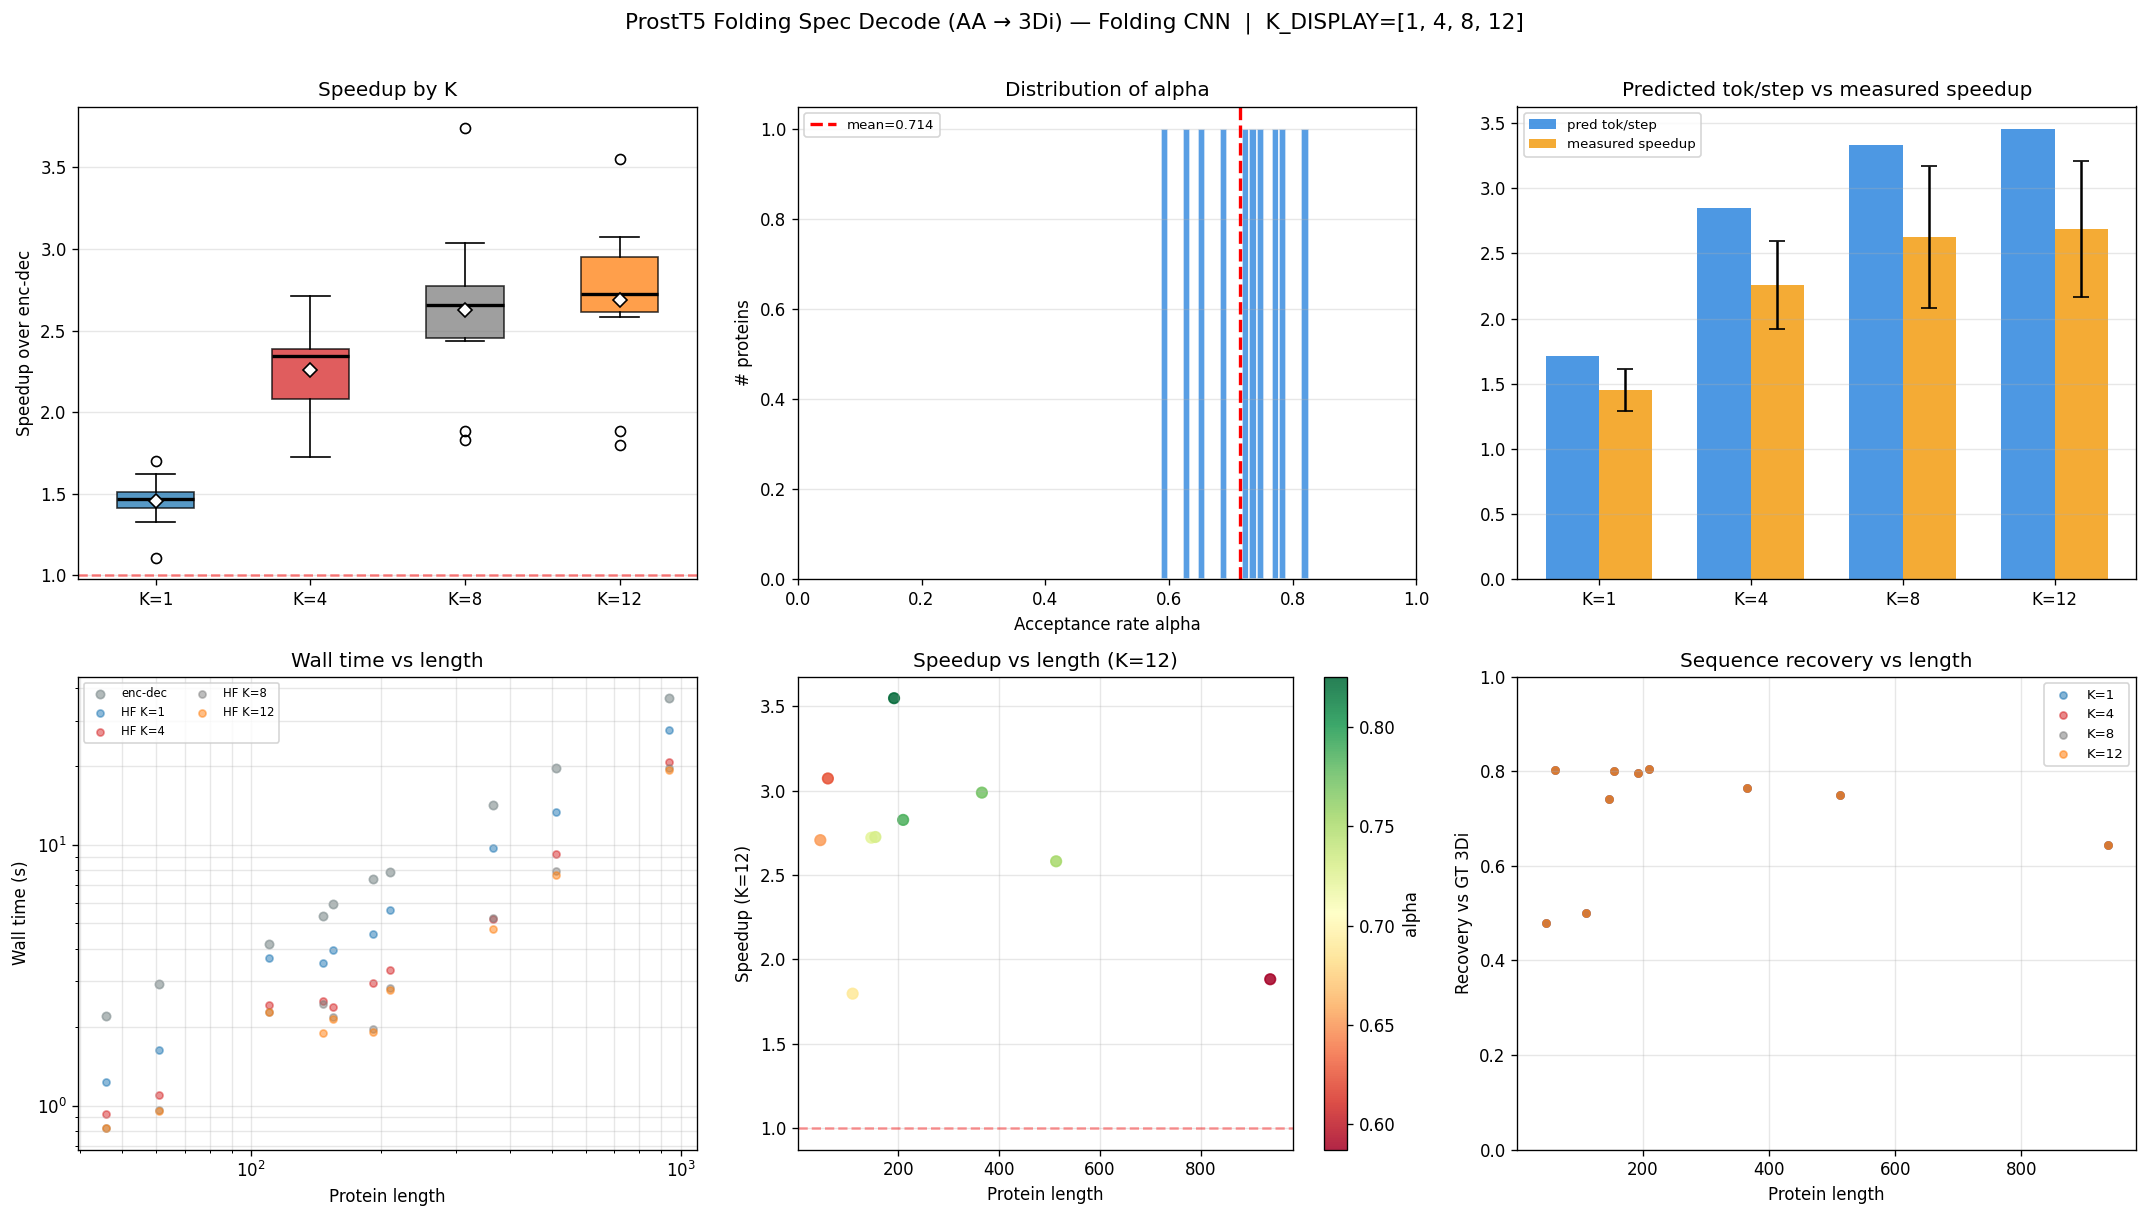

[cnn] saved folding_spec_dec_plots.png


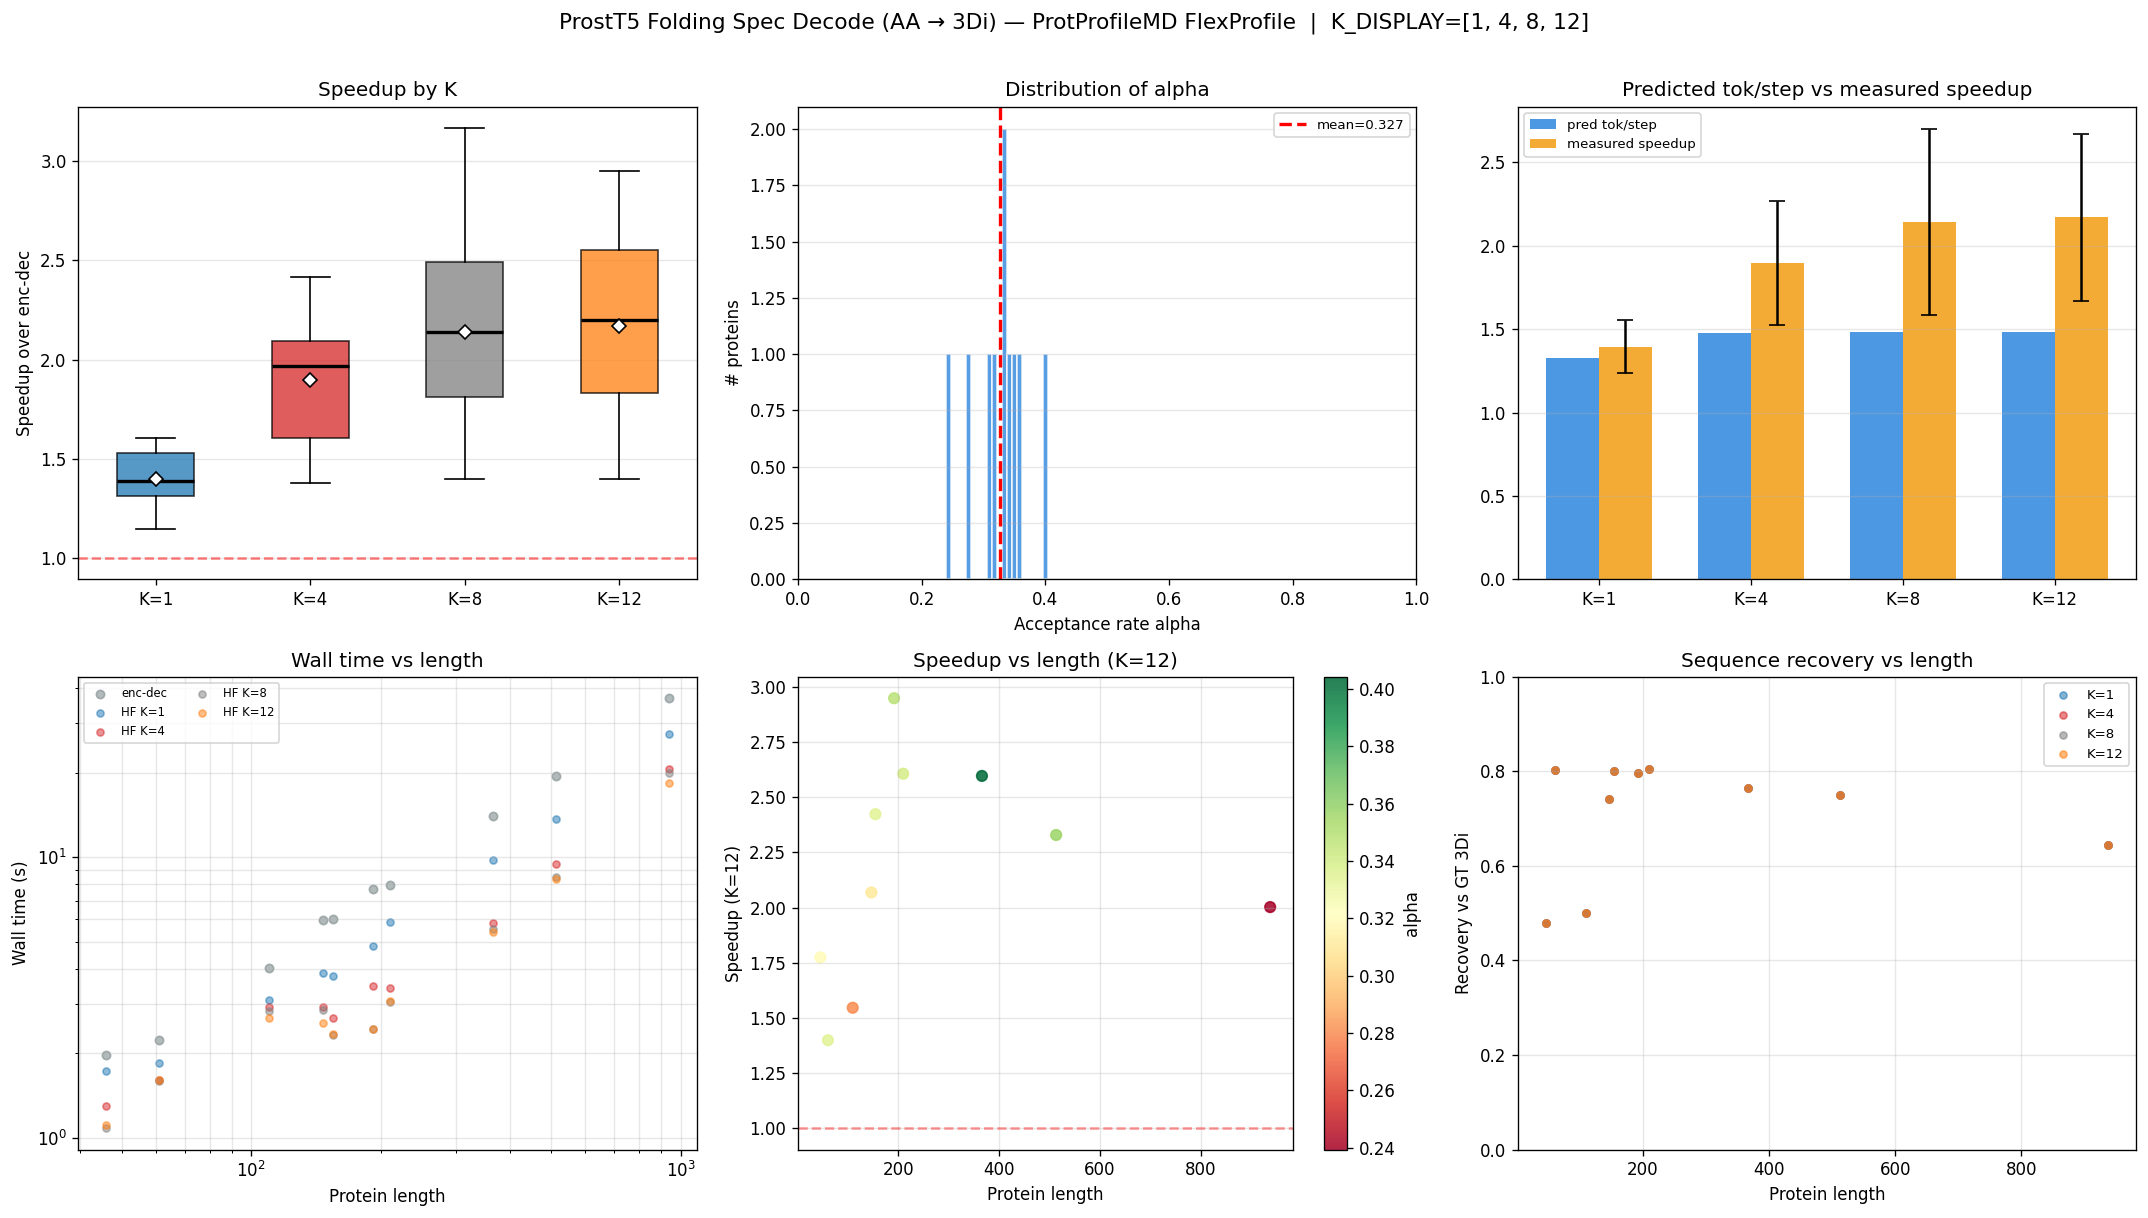

[flexprofile] saved folding_spec_dec_plots.png


In [22]:
# @title 11A. Main results figure (per drafter, 6-panel)
def _save(fig_path, drive_dir=None):
    plt.savefig(fig_path, bbox_inches="tight", dpi=150)
    if USE_DRIVE and drive_dir is not None:
        drive_dir.mkdir(parents=True, exist_ok=True)
        _shutil.copy(fig_path, drive_dir / fig_path.name)

for name in DRAFTER_DISPLAY:
    rdf = results_by_drafter.get(name)
    adf = alpha_by_drafter.get(name)
    if rdf is None or rdf.empty:
        continue
    preds = preds_by_drafter.get(name, {})
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"ProstT5 Folding Spec Decode (AA → 3Di) — {DRAFTER_LABEL[name]}  |  K_DISPLAY={K_DISPLAY}",
                 fontsize=13, y=1.01)
    axes = axes.flatten()

    # 1. speedup boxplot by K
    ax = axes[0]
    valid_K = [K for K in K_DISPLAY if rdf[rdf["K"] == K]["speedup"].notna().any()]
    data_sp = [rdf[rdf["K"] == K]["speedup"].dropna().values for K in valid_K]
    if data_sp:
        bp = ax.boxplot(data_sp, patch_artist=True, widths=0.5, showmeans=True,
                        medianprops={"color": "black", "lw": 2},
                        meanprops={"marker": "D", "markerfacecolor": "white",
                                   "markeredgecolor": "black", "markersize": 6})
        for patch, K in zip(bp["boxes"], valid_K):
            patch.set_facecolor(PALETTE.get(K, BLUE)); patch.set_alpha(0.75)
        ax.set_xticklabels([f"K={K}" for K in valid_K])
    ax.axhline(1.0, color="red", ls="--", alpha=0.5)
    ax.set_ylabel("Speedup over enc-dec"); ax.set_title("Speedup by K"); ax.grid(True, alpha=0.3, axis="y")

    # 2. alpha distribution
    ax = axes[1]
    av = adf["alpha_mean"].dropna() if adf is not None else pd.Series(dtype=float)
    if len(av):
        ax.hist(av, bins=20, color=BLUE, alpha=0.8, edgecolor="white")
        ax.axvline(av.mean(), color="red", ls="--", lw=2, label=f"mean={av.mean():.3f}")
        ax.legend(fontsize=8)
    ax.set_xlabel("Acceptance rate alpha"); ax.set_ylabel("# proteins"); ax.set_xlim(0, 1)
    ax.set_title("Distribution of alpha"); ax.grid(True, alpha=0.3, axis="y")

    # 3. predicted tok/step vs measured speedup
    ax = axes[2]
    mean_a = adf["alpha_mean"].mean() if adf is not None and len(adf) else float("nan")
    K_arr = np.array(K_DISPLAY)
    pred_vals = [pred_tps(mean_a, K) for K in K_arr]
    meas = [rdf[rdf["K"] == K]["speedup"].mean() for K in K_arr]
    meas_std = [rdf[rdf["K"] == K]["speedup"].std() for K in K_arr]
    x = np.arange(len(K_arr)); w = 0.35
    ax.bar(x - w/2, pred_vals, w, color=BLUE, alpha=0.85, label="pred tok/step")
    ax.bar(x + w/2, meas, w, color=ORANGE, alpha=0.85, yerr=meas_std, capsize=5,
           label="measured speedup")
    ax.set_xticks(x); ax.set_xticklabels([f"K={K}" for K in K_arr])
    ax.set_title("Predicted tok/step vs measured speedup"); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

    # 4. wall time vs length
    ax = axes[3]
    sub0 = rdf[rdf["K"] == K_DISPLAY[0]]
    ax.scatter(sub0["length"], sub0["t_encdec"], color=GRAY, alpha=0.6, s=25, label="enc-dec")
    for K in K_DISPLAY:
        sub = rdf[rdf["K"] == K].dropna(subset=["t_hf"])
        ax.scatter(sub["length"], sub["t_hf"], s=18, alpha=0.5,
                   color=PALETTE.get(K, BLUE), label=f"HF K={K}")
    ax.set_xlabel("Protein length"); ax.set_ylabel("Wall time (s)")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_title("Wall time vs length")
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3, which="both")

    # 5. speedup vs length (best K, coloured by alpha)
    ax = axes[4]
    best_K = K_DISPLAY[int(np.nanargmax([rdf[rdf["K"] == K]["speedup"].mean() for K in K_DISPLAY]))]
    sub = rdf[rdf["K"] == best_K].dropna(subset=["speedup", "alpha_mean"])
    if len(sub):
        sc = ax.scatter(sub["length"], sub["speedup"], c=sub["alpha_mean"], cmap="RdYlGn",
                        s=40, alpha=0.85)
        fig.colorbar(sc, ax=ax, label="alpha")
    ax.axhline(1.0, color="red", ls="--", alpha=0.4)
    ax.set_xlabel("Protein length"); ax.set_ylabel(f"Speedup (K={best_K})")
    ax.set_title(f"Speedup vs length (K={best_K})"); ax.grid(True, alpha=0.3)

    # 6. sequence recovery vs length
    ax = axes[5]
    for K in K_DISPLAY:
        ks = str(K); rv, ln = [], []
        for item in benchmark_data:
            uid, gt = item["id"], item["3Di"]
            pred = preds.get(uid, {}).get("preds_by_K", {}).get(ks, "")
            if pred:
                rv.append(seq_recovery(pred, gt)); ln.append(len(gt))
        ax.scatter(ln, rv, color=PALETTE.get(K, BLUE), alpha=0.55, s=18, label=f"K={K}")
    ax.set_xlabel("Protein length"); ax.set_ylabel("Recovery vs GT 3Di")
    ax.set_ylim(0, 1); ax.set_title("Sequence recovery vs length"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    _save(PATHS[name]["dir"] / "folding_spec_dec_plots.png", PATHS[name]["drive_dir"])
    plt.show()
    print(f"[{name}] saved folding_spec_dec_plots.png")

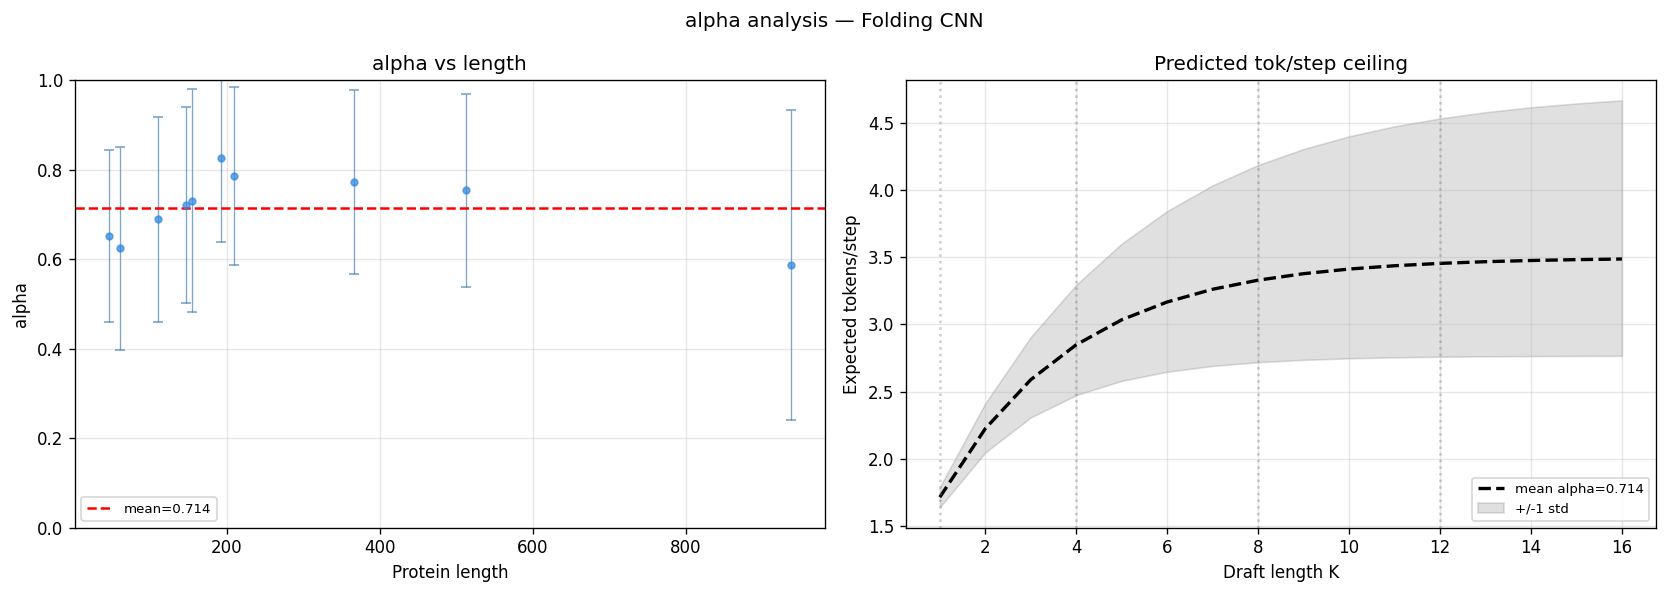

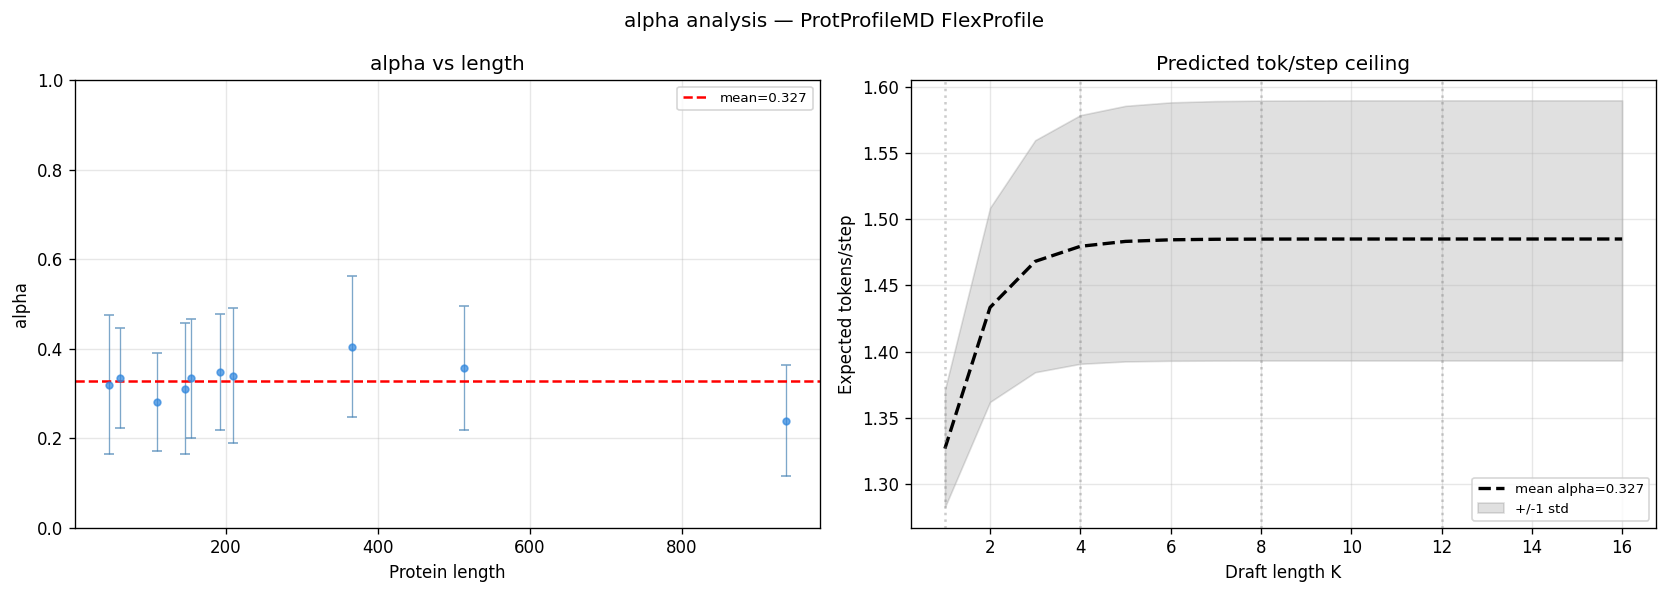

In [23]:
# @title 11B. alpha vs length + speedup-ceiling curve (per drafter)
for name in DRAFTER_DISPLAY:
    adf = alpha_by_drafter.get(name)
    if adf is None or adf.empty:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"alpha analysis — {DRAFTER_LABEL[name]}", fontsize=12)
    ax = axes[0]
    ax.errorbar(adf["length"], adf["alpha_mean"], yerr=adf["alpha_std"], fmt="o",
                color=BLUE, alpha=0.7, ecolor="steelblue", elinewidth=0.8, capsize=3, markersize=4)
    ax.axhline(adf["alpha_mean"].mean(), color="red", ls="--",
               label=f"mean={adf['alpha_mean'].mean():.3f}")
    ax.set_xlabel("Protein length"); ax.set_ylabel("alpha"); ax.set_ylim(0, 1)
    ax.set_title("alpha vs length"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1]
    K_range = np.arange(1, 17)
    mean_a = adf["alpha_mean"].mean(); std_a = adf["alpha_mean"].std()
    tps_mean = [pred_tps(mean_a, K) for K in K_range]
    a_lo, a_hi = max(0.01, mean_a - std_a), min(0.999, mean_a + std_a)
    ax.plot(K_range, tps_mean, "k--", lw=2, label=f"mean alpha={mean_a:.3f}")
    ax.fill_between(K_range, [pred_tps(a_lo, K) for K in K_range],
                    [pred_tps(a_hi, K) for K in K_range], color="black", alpha=0.12,
                    label=f"+/-1 std")
    for K in K_DISPLAY:
        ax.axvline(K, color="gray", ls=":", alpha=0.4)
    ax.set_xlabel("Draft length K"); ax.set_ylabel("Expected tokens/step")
    ax.set_title("Predicted tok/step ceiling"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save(PATHS[name]["dir"] / "folding_alpha_analysis.png", PATHS[name]["drive_dir"])
    plt.show()

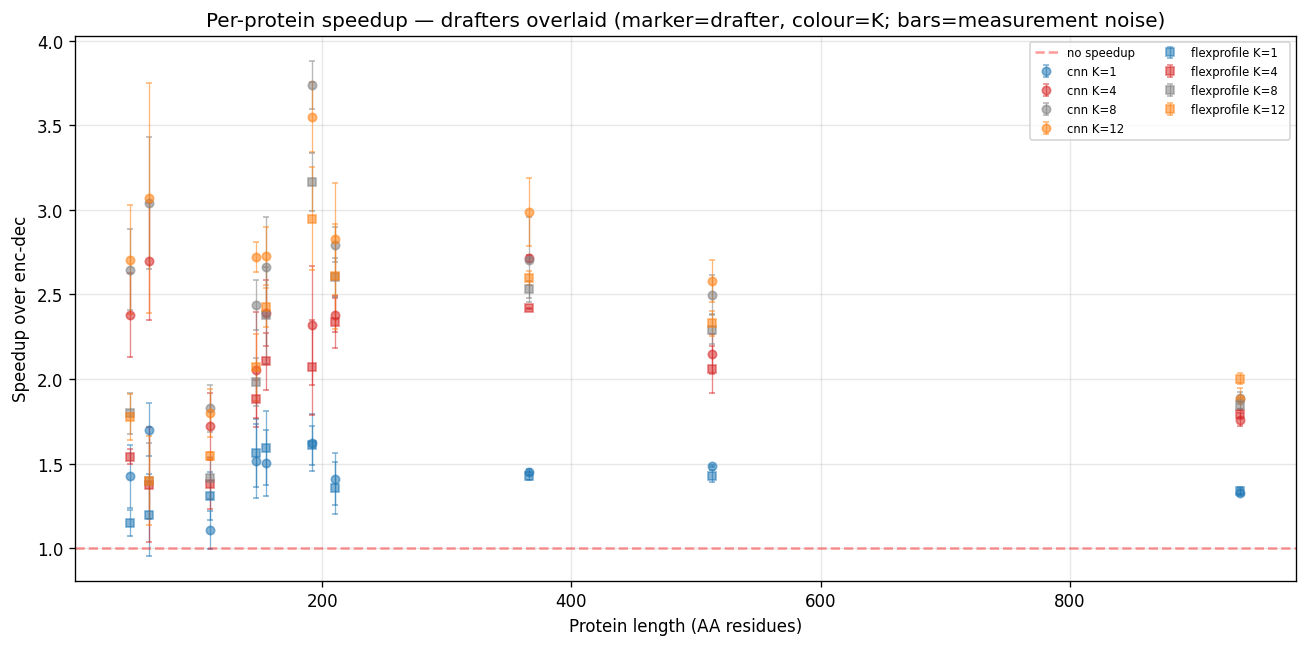

In [24]:
# @title 11C. Per-protein speedup scatter — drafters overlaid (with measurement-noise bars)
# Error bars = per-protein `speedup_std` = spread of the interleaved per-repeat
# ratios = TRUE measurement noise. With interleaving these should be small; large
# bars mean the GPU still is not thermally stable (raise NUM_WARMUP / NUM_REPEATS).
fig, ax = plt.subplots(figsize=(11, 5.5))
for name in DRAFTER_DISPLAY:
    rdf = results_by_drafter.get(name)
    if rdf is None or rdf.empty:
        continue
    for K in K_DISPLAY:
        sub = rdf[rdf["K"] == K].dropna(subset=["speedup"]).sort_values("length")
        yerr = sub["speedup_std"] if "speedup_std" in sub.columns else None
        ax.errorbar(sub["length"], sub["speedup"], yerr=yerr,
                    fmt=DRAFTER_MARKER[name], ms=5, alpha=0.55, capsize=2, elinewidth=0.8,
                    color=PALETTE.get(K, BLUE), label=f"{name} K={K}")
ax.axhline(1.0, color="red", ls="--", alpha=0.4, label="no speedup")
ax.set_xlabel("Protein length (AA residues)"); ax.set_ylabel("Speedup over enc-dec")
ax.set_title("Per-protein speedup — drafters overlaid (marker=drafter, colour=K; bars=measurement noise)")
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
_save(COMPARISON_DIR / "per_protein_speedup.png", DRIVE_COMPARISON_DIR)
plt.show()

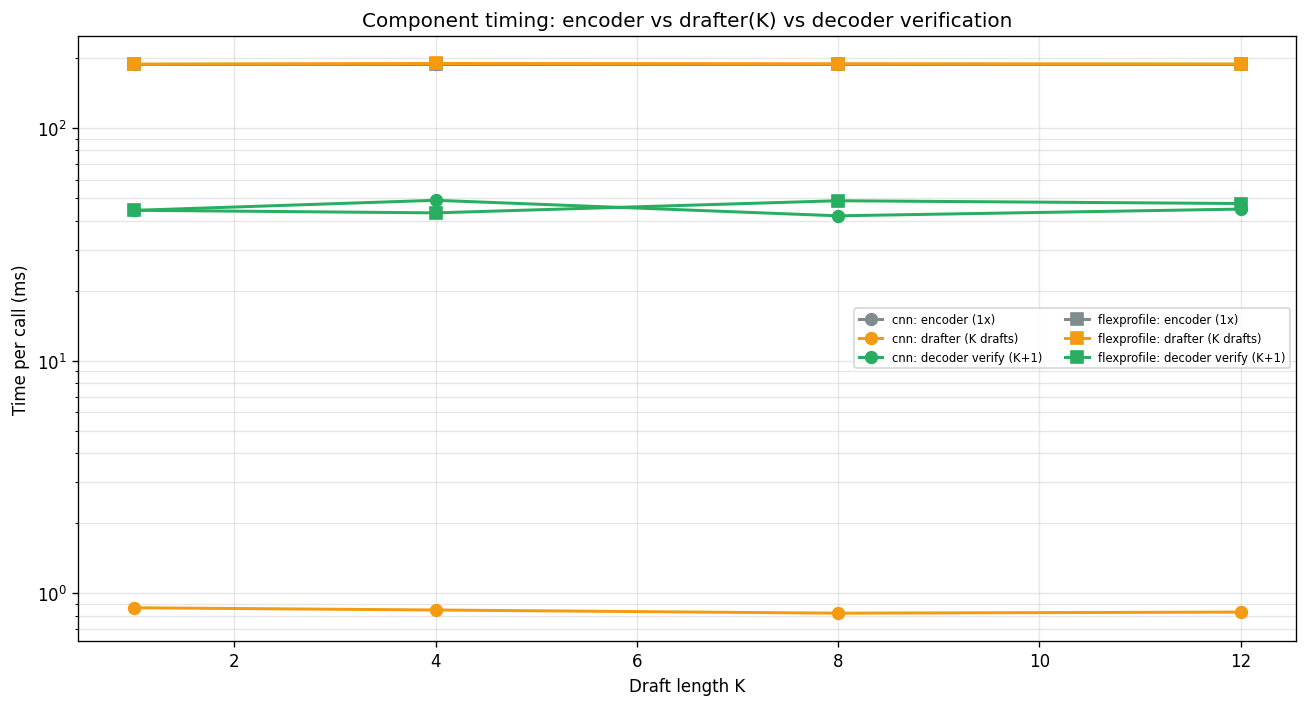

In [25]:
# @title 11D. Timing breakdown: encoder vs drafter(K) vs decoder-verify (overlaid)
# Uses overhead_by_drafter (Section 8). Lines = drafter (marker) x component (colour).
fig, ax = plt.subplots(figsize=(11, 6))
COMP_COLOR = {"t_encoder": GRAY, "t_drafter": ORANGE, "t_decoder_verify": GREEN}
COMP_LABEL = {"t_encoder": "encoder (1x)", "t_drafter": "drafter (K drafts)",
              "t_decoder_verify": "decoder verify (K+1)"}
have_any = False
for name in DRAFTER_DISPLAY:
    odf = overhead_by_drafter.get(name)
    if odf is None or odf.empty:
        continue
    have_any = True
    g = odf.groupby("K")[["t_encoder", "t_drafter", "t_decoder_verify"]].mean() * 1e3  # ms
    for comp in ["t_encoder", "t_drafter", "t_decoder_verify"]:
        ax.plot(g.index, g[comp], marker=DRAFTER_MARKER[name], color=COMP_COLOR[comp],
                lw=1.8, ms=7, label=f"{name}: {COMP_LABEL[comp]}")
if have_any:
    ax.set_xlabel("Draft length K"); ax.set_ylabel("Time per call (ms)")
    ax.set_yscale("log")
    ax.set_title("Component timing: encoder vs drafter(K) vs decoder verification")
    ax.legend(fontsize=7, ncol=len(DRAFTER_DISPLAY)); ax.grid(True, alpha=0.3, which="both")
    plt.tight_layout()
    _save(COMPARISON_DIR / "timing_breakdown.png", DRIVE_COMPARISON_DIR)
    plt.show()
else:
    print("No overhead data — run Section 8 first.")

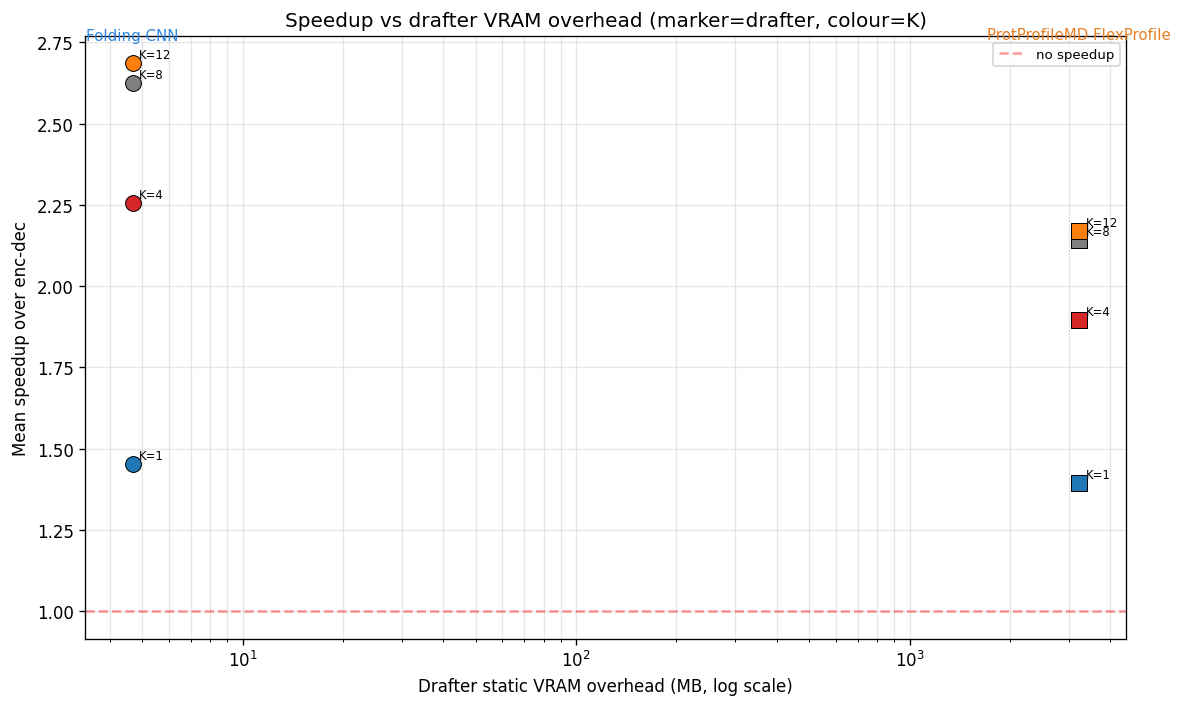

In [26]:
# @title 11E. Speedup per drafter & per K vs drafter VRAM overhead
# x = drafter static VRAM overhead (MB, log); y = mean speedup; one point per (drafter, K).
fig, ax = plt.subplots(figsize=(10, 6))
plotted = False
for name in DRAFTER_DISPLAY:
    rdf = results_by_drafter.get(name)
    if rdf is None or rdf.empty:
        continue
    vram_mb = max(DRAFTER_VRAM.get(name, 0) / 1e6, 0.05)  # floor so log-x shows ~0 overhead CNN
    for K in K_DISPLAY:
        sub = rdf[rdf["K"] == K]
        if sub.empty:
            continue
        sp = sub["speedup"].mean()
        ax.scatter(vram_mb, sp, s=90, marker=DRAFTER_MARKER[name],
                   color=PALETTE.get(K, BLUE), edgecolors="black", linewidths=0.6, zorder=3)
        ax.annotate(f"K={K}", (vram_mb, sp), fontsize=7, xytext=(4, 3),
                    textcoords="offset points")
        plotted = True
    ax.annotate(DRAFTER_LABEL[name], (vram_mb, ax.get_ylim()[1]),
                fontsize=9, ha="center", va="bottom", color=DRAFTER_COLOR[name])
if plotted:
    ax.axhline(1.0, color="red", ls="--", alpha=0.4, label="no speedup")
    ax.set_xscale("log")
    ax.set_xlabel("Drafter static VRAM overhead (MB, log scale)")
    ax.set_ylabel("Mean speedup over enc-dec")
    ax.set_title("Speedup vs drafter VRAM overhead (marker=drafter, colour=K)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which="both")
    plt.tight_layout()
    _save(COMPARISON_DIR / "speedup_vs_vram_overhead.png", DRIVE_COMPARISON_DIR)
    plt.show()
else:
    print("No results to plot.")

## 12. Final Summary

In [27]:
# @title 12. Final summary
print("=" * 72)
print("FINAL SUMMARY — ProstT5 Folding Speculative Decoding (AA → 3Di)")
print("=" * 72)
print(f"  Device   : {device}")
print(f"  Proteins : {len(benchmark_data)}")
print(f"  Verifier : ProstT5 enc-dec ({sum(p.numel() for p in model.parameters())/1e6:.0f}M params)")
print()
for name in DRAFTER_DISPLAY:
    rdf = results_by_drafter.get(name)
    adf = alpha_by_drafter.get(name)
    if rdf is None or rdf.empty:
        continue
    mean_a = adf["alpha_mean"].mean() if adf is not None and len(adf) else float("nan")
    best_K = K_DISPLAY[int(np.nanargmax([rdf[rdf["K"] == K]["speedup"].mean() for K in K_DISPLAY]))]
    best_sp = rdf[rdf["K"] == best_K]["speedup"].mean()
    vram = DRAFTER_VRAM.get(name, 0)
    vram_s = f"{vram/1e9:.2f} GB" if vram >= 1e8 else f"{vram/1e6:.1f} MB"
    print(f"  {DRAFTER_LABEL[name]}")
    print(f"     params {DRAFTER_PARAMS.get(name,0):,}  |  VRAM overhead {vram_s}  |  mean alpha {mean_a:.4f}")
    print(f"     best K={best_K} -> {best_sp:.2f}x  |  ceiling 1/(1-alpha)={1/(1-mean_a):.2f}x")
    print()
print("Comparison plots (timing breakdown, speedup-vs-VRAM) in:", COMPARISON_DIR)
print("=" * 72)

FINAL SUMMARY — ProstT5 Folding Speculative Decoding (AA → 3Di)
  Device   : cuda:0
  Proteins : 10
  Verifier : ProstT5 enc-dec (2819M params)

  Folding CNN
     params 233,908  |  VRAM overhead 4.7 MB  |  mean alpha 0.7140
     best K=12 -> 2.69x  |  ceiling 1/(1-alpha)=3.50x

  ProtProfileMD FlexProfile
     params 1,208,184,852  |  VRAM overhead 3.22 GB  |  mean alpha 0.3266
     best K=12 -> 2.17x  |  ceiling 1/(1-alpha)=1.49x

Comparison plots (timing breakdown, speedup-vs-VRAM) in: /content/benchmark_results/folding_spec_dec/comparison
